# Gold Recovery from Ore

**Project Objective:**

- Develop a **machine-learning model prototype** that predicts the **gold recovery rate from gold-bearing ore** using mining and purification process parameters.

**Project Description**

The objective is to develop a machine-learning model prototype for Zyfra, a company that creates solutions designed to improve the efficiency of industrial operations.

The model must forecast the gold recovery rate from gold-bearing ore using mining and purification process parameters.

Predicting the recovery rate requires estimating two outcomes: recovery from the **rougher concentrate** and recovery from the **final concentrate**. Both stages are important because the project metric combines the **quality of the two predictions**.

The predictions may help identify operating periods or process configurations associated with low recovery before additional resources are spent. However, the model estimates recovery rather than proving which settings cause it to change, so it should be treated as a predictive prototype rather than an automatic process-control system.

The project includes the following steps:

1. Prepare and validate the data.
2. Perform exploratory data analysis.
3. Build, validate, and compare predictive models.

**Data Description:**

***Parameters:***

**Process Stages and Terms**
- Rougher feed - raw material
- Rougher additions (or reagent additions) - flotation reagents: xanthate, sulphate, and depressant
  - Xanthate - a flotation promoter or activator
  - Sulphate - sodium sulphide in this process
  - Depressant - sodium silicate
- Rougher process - flotation
- Rougher tails - discarded tailings
- Float banks - flotation units
- Cleaner process -purification
- Rougher Au - rougher gold concentrate
- Final Au - final gold concentrate

**Stage Parameters**
- air amount - volume of air
- fluid levels - liquid level
- feed size - feed particle size
- feed rate - feed flow rate

**Feature Naming Convention**

*Feature names follow this pattern:*

- [stage].[parameter_type].[parameter_name]
- Example: `rougher.input.feed_ag`

*Possible values of the [stage] component:*
- rougher - flotation
- primary_cleaner - primary purification
- secondary_cleaner - secondary purification
- final - final product characteristics

*Possible values of the [parameter_type] component:*
- input - raw-material parameters
- output - product parameters
- state - parameters describing the current state of the process stage
- calculation - calculated characteristics

***Datasets:***

The data are stored in three files:

`gold_industry_train.csv` - training set;

`gold_industry_test.csv` - test set;

`gold_industry_full.csv` - complete source dataset.

The data are indexed by the date and time at which the measurements were obtained (`date`). Observations adjacent in time often have similar parameter values.

Some parameters are unavailable because they are measured and/or calculated considerably later. Therefore, the **test set** does not contain some features that are present in the training set.

The test set also does not contain the **target features**.

**The complete source dataset contains the training and test observations with all features.**

The data are raw exports from the data warehouse and must be validated before modeling.

***Evaluation Metrics:***

**Recovery Calculation**

The process to be modeled is the recovery of gold from gold-bearing ore. The **recovery rate** is calculated using the following formula:

![Gold recovery formula](https://pictures.s3.yandex.net/resources/Recovery_1576238822.jpg)

where:

- C is the proportion of gold in the concentrate after flotation/purification;
- F is the proportion of gold in the feed/concentrate before flotation/purification;
- T is the proportion of gold in the discarded tailings after flotation/purification.

Predicting the recovery rate requires estimating the proportion of gold in the concentrates and tailings. Both the rougher concentrate and the final product are important.

**Evaluation Metric**

The project uses **sMAPE (Symmetric Mean Absolute Percentage Error)** as its evaluation metric. It is similar to MAE but expresses the error in relative rather than absolute terms. It is symmetric because it accounts for the scale of both the target and the prediction in the same way.

sMAPE is calculated using the following formula:

![sMAPE formula](https://pictures.s3.yandex.net/resources/smape_1576239058.jpg)

*Notation:*

![Target value](https://pictures.s3.yandex.net/resources/y1_1576238832.jpg)

The target value for observation *i* in the dataset on which model quality is evaluated.

![Predicted value](https://pictures.s3.yandex.net/resources/yi_1_1576238835.jpg)

The predicted value for observation *i*, for example in the test set.

![Number of observations](https://pictures.s3.yandex.net/resources/N_1_1576238819.jpg)

The number of observations in the dataset.

![Summation symbol](https://pictures.s3.yandex.net/resources/I_1576238817.jpg)

Summation over all observations in the dataset, where *i* ranges from 1 to *N*.

Two values must be predicted:

- the **rougher concentrate recovery rate**, `rougher.output.recovery`;
- the **final concentrate recovery rate**, `final.output.recovery`.

**The final metric combines these two values:**

![Final sMAPE formula](https://pictures.s3.yandex.net/resources/_smape_1576239054.jpg)

## Data Preparation

### Data Loading and Initial Inspection

In [210]:
%pip install -q phik catboost jinja2

Note: you may need to restart the kernel to use updated packages.


In [211]:
# Import the required libraries
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import phik  # registers the pandas Phi_K accessor

from IPython.display import Image, display

from sklearn.metrics import mean_absolute_error, make_scorer
from sklearn.model_selection import cross_val_score, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor
from catboost import CatBoostRegressor

# Fix the random seed for reproducibility
RANDOM_STATE = 678

In [212]:
# Load the datasets from the first available location
def load_dataset(filename):
    local_candidates = [
        Path("/datasets") / filename,
        Path("data") / filename,
        Path(filename),
    ]

    for path in local_candidates:
        if path.exists():
            return pd.read_csv(path)

    base_url = "https://code.s3.yandex.net/datasets"
    return pd.read_csv(f"{base_url}/{filename}")


train = load_dataset("gold_industry_train.csv")
test = load_dataset("gold_industry_test.csv")
full = load_dataset("gold_industry_full.csv")

First, we examine the initial data characteristics.

We create a list of DataFrames so that all datasets can be processed together.

In [213]:
# List of DataFrames
dataframes = [
    ("train", train),
    ("test", test),
    ("full", full),
]

We inspecte the first rows of each table.

In [214]:
pd.set_option('display.max_columns', None)  # display all columns

In [215]:
for name, df in dataframes:
    display(f'Information about {name}:')
    display(df.head(2))

'Information about train:'

,date,rougher.input.feed_au,rougher.input.feed_ag,rougher.input.feed_pb,rougher.input.feed_sol,rougher.input.feed_rate,rougher.input.feed_size,rougher.input.floatbank10_sulfate,rougher.input.floatbank10_xanthate,rougher.state.floatbank10_a_air,rougher.state.floatbank10_a_level,rougher.state.floatbank10_b_air,rougher.state.floatbank10_b_level,rougher.state.floatbank10_c_air,rougher.state.floatbank10_c_level,rougher.state.floatbank10_d_air,rougher.state.floatbank10_d_level,rougher.state.floatbank10_e_air,rougher.state.floatbank10_e_level,rougher.state.floatbank10_f_air,rougher.state.floatbank10_f_level,rougher.input.floatbank11_sulfate,rougher.input.floatbank11_xanthate,rougher.calculation.sulfate_to_au_concentrate,rougher.calculation.floatbank10_sulfate_to_au_feed,rougher.calculation.floatbank11_sulfate_to_au_feed,rougher.calculation.au_pb_ratio,rougher.output.concentrate_au,rougher.output.concentrate_ag,rougher.output.concentrate_pb,rougher.output.concentrate_sol,rougher.output.recovery,rougher.output.tail_au,rougher.output.tail_ag,rougher.output.tail_pb,rougher.output.tail_sol,primary_cleaner.input.sulfate,primary_cleaner.input.depressant,primary_cleaner.input.feed_size,primary_cleaner.input.xanthate,primary_cleaner.state.floatbank8_a_air,primary_cleaner.state.floatbank8_a_level,primary_cleaner.state.floatbank8_b_air,primary_cleaner.state.floatbank8_b_level,primary_cleaner.state.floatbank8_c_air,primary_cleaner.state.floatbank8_c_level,primary_cleaner.state.floatbank8_d_air,primary_cleaner.state.floatbank8_d_level,primary_cleaner.output.concentrate_au,primary_cleaner.output.concentrate_ag,primary_cleaner.output.concentrate_pb,primary_cleaner.output.concentrate_sol,primary_cleaner.output.tail_au,primary_cleaner.output.tail_ag,primary_cleaner.output.tail_pb,primary_cleaner.output.tail_sol,secondary_cleaner.state.floatbank2_a_air,secondary_cleaner.state.floatbank2_a_level,secondary_cleaner.state.floatbank2_b_air,secondary_cleaner.state.floatbank2_b_level,secondary_cleaner.state.floatbank3_a_air,secondary_cleaner.state.floatbank3_a_level,secondary_cleaner.state.floatbank3_b_air,secondary_cleaner.state.floatbank3_b_level,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level,secondary_cleaner.output.tail_au,secondary_cleaner.output.tail_ag,secondary_cleaner.output.tail_pb,secondary_cleaner.output.tail_sol,final.output.concentrate_au,final.output.concentrate_ag,final.output.concentrate_pb,final.output.concentrate_sol,final.output.recovery,final.output.tail_au,final.output.tail_ag,final.output.tail_pb,final.output.tail_sol
0,2016-01-15 00:00:00,6.486150,6.100378,2.284912,36.808594,523.546326,55.486599,11.986616,6.007990,999.706909,-404.066986,1603.011353,-434.715027,1602.37500,-442.204468,1598.937256,-451.294128,1404.472046,-455.462982,1416.354980,-451.939636,11.836743,6.005818,41885.707031,3481.779053,3520.337158,2.838687,19.793808,11.500771,7.101074,28.029297,87.107763,1.170244,5.008018,0.508728,19.154297,127.092003,10.128295,7.25,0.988759,1549.775757,-498.912140,1551.434204,-516.403442,1549.873901,-498.666595,1554.367432,-493.428131,34.174427,8.547551,10.389648,19.529297,2.106679,14.936526,2.534912,7.476074,25.853109,-498.526489,23.89366,-501.406281,23.961798,-495.262817,21.940409,-499.340973,14.016835,-502.488007,12.099931,-504.715942,9.925633,-498.310211,8.079666,-500.470978,14.151341,-605.841980,2.606185,14.500184,4.694824,8.764648,42.192020,6.055403,9.889648,5.507324,70.541216,2.143149,10.411962,0.895447,16.904297
1,2016-01-15 01:00:00,6.478583,6.161113,2.266033,35.753385,525.290581,57.278666,11.971193,6.005766,1000.286398,-400.065196,1600.754587,-449.953435,1600.4795

'Information about test:'

,date,rougher.input.feed_au,rougher.input.feed_ag,rougher.input.feed_pb,rougher.input.feed_sol,rougher.input.feed_rate,rougher.input.feed_size,rougher.input.floatbank10_sulfate,rougher.input.floatbank10_xanthate,rougher.state.floatbank10_a_air,rougher.state.floatbank10_a_level,rougher.state.floatbank10_b_air,rougher.state.floatbank10_b_level,rougher.state.floatbank10_c_air,rougher.state.floatbank10_c_level,rougher.state.floatbank10_d_air,rougher.state.floatbank10_d_level,rougher.state.floatbank10_e_air,rougher.state.floatbank10_e_level,rougher.state.floatbank10_f_air,rougher.state.floatbank10_f_level,rougher.input.floatbank11_sulfate,rougher.input.floatbank11_xanthate,primary_cleaner.input.sulfate,primary_cleaner.input.depressant,primary_cleaner.input.feed_size,primary_cleaner.input.xanthate,primary_cleaner.state.floatbank8_a_air,primary_cleaner.state.floatbank8_a_level,primary_cleaner.state.floatbank8_b_air,primary_cleaner.state.floatbank8_b_level,primary_cleaner.state.floatbank8_c_air,primary_cleaner.state.floatbank8_c_level,primary_cleaner.state.floatbank8_d_air,primary_cleaner.state.floatbank8_d_level,secondary_cleaner.state.floatbank2_a_air,secondary_cleaner.state.floatbank2_a_level,secondary_cleaner.state.floatbank2_b_air,secondary_cleaner.state.floatbank2_b_level,secondary_cleaner.state.floatbank3_a_air,secondary_cleaner.state.floatbank3_a_level,secondary_cleaner.state.floatbank3_b_air,secondary_cleaner.state.floatbank3_b_level,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level
0,2017-12-09 14:59:59,4.365491,6.158718,3.875727,39.135119,555.820208,94.544358,6.146982,9.308612,1196.238112,-299.862743,1147.248241,-500.363165,1047.279065,-500.354091,948.756608,-498.439416,849.441918,-499.255503,850.112246,-499.407112,6.168939,9.309852,95.248427,8.078957,6.5,1.283045,1648.759906,-399.862053,1650.135395,-399.957321,1648.831890,-400.586116,1649.464582,-400.673303,34.940919,-500.150510,30.031867,-500.328335,26.033990,-500.147792,22.952306,-500.037678,23.018622,-500.492702,20.020205,-500.220296,17.963512,-499.939490,12.990306,-500.080993,19.990336,-499.191575
1,2017-12-09 15:59:59,4.362781,6.048130,3.902537,39.713906,544.731687,123.742430,6.210119,9.297709,1201.904177,-299.907308,1154.087804,-500.036580,1054.009756,-500.237335,944.138793,-496.866953,851.589767,-499.040466,851.345606,-499.122561,6.209517,9.297194,98.880538,7.984164,6.5,1.241969,1646.547763,-398.977083,1648.212240,-400.383265,1648.917387,-399.521344,1651.498591,-399.745329,34.980742,-498.131002,29.968453,-586.013330,25.971737,-499.608392,22.958448,-499.821308,23.024963,-501.153409,20.054122,-500.314711,17.979515,-499.272871,12.992404,-499.976268,20.013986,-500.625471


'Information about full:'

,date,rougher.input.feed_au,rougher.input.feed_ag,rougher.input.feed_pb,rougher.input.feed_sol,rougher.input.feed_rate,rougher.input.feed_size,rougher.input.floatbank10_sulfate,rougher.input.floatbank10_xanthate,rougher.state.floatbank10_a_air,rougher.state.floatbank10_a_level,rougher.state.floatbank10_b_air,rougher.state.floatbank10_b_level,rougher.state.floatbank10_c_air,rougher.state.floatbank10_c_level,rougher.state.floatbank10_d_air,rougher.state.floatbank10_d_level,rougher.state.floatbank10_e_air,rougher.state.floatbank10_e_level,rougher.state.floatbank10_f_air,rougher.state.floatbank10_f_level,rougher.input.floatbank11_sulfate,rougher.input.floatbank11_xanthate,rougher.calculation.sulfate_to_au_concentrate,rougher.calculation.floatbank10_sulfate_to_au_feed,rougher.calculation.floatbank11_sulfate_to_au_feed,rougher.calculation.au_pb_ratio,rougher.output.concentrate_au,rougher.output.concentrate_ag,rougher.output.concentrate_pb,rougher.output.concentrate_sol,rougher.output.recovery,rougher.output.tail_au,rougher.output.tail_ag,rougher.output.tail_pb,rougher.output.tail_sol,primary_cleaner.input.sulfate,primary_cleaner.input.depressant,primary_cleaner.input.feed_size,primary_cleaner.input.xanthate,primary_cleaner.state.floatbank8_a_air,primary_cleaner.state.floatbank8_a_level,primary_cleaner.state.floatbank8_b_air,primary_cleaner.state.floatbank8_b_level,primary_cleaner.state.floatbank8_c_air,primary_cleaner.state.floatbank8_c_level,primary_cleaner.state.floatbank8_d_air,primary_cleaner.state.floatbank8_d_level,primary_cleaner.output.concentrate_au,primary_cleaner.output.concentrate_ag,primary_cleaner.output.concentrate_pb,primary_cleaner.output.concentrate_sol,primary_cleaner.output.tail_au,primary_cleaner.output.tail_ag,primary_cleaner.output.tail_pb,primary_cleaner.output.tail_sol,secondary_cleaner.state.floatbank2_a_air,secondary_cleaner.state.floatbank2_a_level,secondary_cleaner.state.floatbank2_b_air,secondary_cleaner.state.floatbank2_b_level,secondary_cleaner.state.floatbank3_a_air,secondary_cleaner.state.floatbank3_a_level,secondary_cleaner.state.floatbank3_b_air,secondary_cleaner.state.floatbank3_b_level,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level,secondary_cleaner.output.tail_au,secondary_cleaner.output.tail_ag,secondary_cleaner.output.tail_pb,secondary_cleaner.output.tail_sol,final.output.concentrate_au,final.output.concentrate_ag,final.output.concentrate_pb,final.output.concentrate_sol,final.output.recovery,final.output.tail_au,final.output.tail_ag,final.output.tail_pb,final.output.tail_sol
0,2016-01-15 00:00:00,6.486150,6.100378,2.284912,36.808594,523.546326,55.486599,11.986616,6.007990,999.706909,-404.066986,1603.011353,-434.715027,1602.37500,-442.204468,1598.937256,-451.294128,1404.472046,-455.462982,1416.354980,-451.939636,11.836743,6.005818,41885.707031,3481.779053,3520.337158,2.838687,19.793808,11.500771,7.101074,28.029297,87.107763,1.170244,5.008018,0.508728,19.154297,127.092003,10.128295,7.25,0.988759,1549.775757,-498.912140,1551.434204,-516.403442,1549.873901,-498.666595,1554.367432,-493.428131,34.174427,8.547551,10.389648,19.529297,2.106679,14.936526,2.534912,7.476074,25.853109,-498.526489,23.89366,-501.406281,23.961798,-495.262817,21.940409,-499.340973,14.016835,-502.488007,12.099931,-504.715942,9.925633,-498.310211,8.079666,-500.470978,14.151341,-605.841980,2.606185,14.500184,4.694824,8.764648,42.192020,6.055403,9.889648,5.507324,70.541216,2.143149,10.411962,0.895447,16.904297
1,2016-01-15 01:00:00,6.478583,6.161113,2.266033,35.753385,525.290581,57.278666,11.971193,6.005766,1000.286398,-400.065196,1600.754587,-449.953435,1600.4795

The tables appear to be structurally valid.

Now, we examine the data types and completeness of each table.

In [216]:
for name, df in dataframes:
    display(f'Information about {name}:')
    df.info()

'Information about train:'

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14579 entries, 0 to 14578
Data columns (total 87 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   date                                                14579 non-null  object 
 1   rougher.input.feed_au                               14579 non-null  float64
 2   rougher.input.feed_ag                               14579 non-null  float64
 3   rougher.input.feed_pb                               14507 non-null  float64
 4   rougher.input.feed_sol                              14502 non-null  float64
 5   rougher.input.feed_rate                             14572 non-null  float64
 6   rougher.input.feed_size                             14478 non-null  float64
 7   rougher.input.floatbank10_sulfate                   14548 non-null  float64
 8   rougher.input.floatbank10_xanthate                  14572 non-null  float64


'Information about test:'

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4860 entries, 0 to 4859
Data columns (total 53 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   date                                        4860 non-null   object 
 1   rougher.input.feed_au                       4860 non-null   float64
 2   rougher.input.feed_ag                       4860 non-null   float64
 3   rougher.input.feed_pb                       4832 non-null   float64
 4   rougher.input.feed_sol                      4838 non-null   float64
 5   rougher.input.feed_rate                     4856 non-null   float64
 6   rougher.input.feed_size                     4816 non-null   float64
 7   rougher.input.floatbank10_sulfate           4857 non-null   float64
 8   rougher.input.floatbank10_xanthate          4859 non-null   float64
 9   rougher.state.floatbank10_a_air             4859 non-null   float64
 10  rougher.stat

'Information about full:'

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19439 entries, 0 to 19438
Data columns (total 87 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   date                                                19439 non-null  object 
 1   rougher.input.feed_au                               19439 non-null  float64
 2   rougher.input.feed_ag                               19439 non-null  float64
 3   rougher.input.feed_pb                               19339 non-null  float64
 4   rougher.input.feed_sol                              19340 non-null  float64
 5   rougher.input.feed_rate                             19428 non-null  float64
 6   rougher.input.feed_size                             19294 non-null  float64
 7   rougher.input.floatbank10_sulfate                   19405 non-null  float64
 8   rougher.input.floatbank10_xanthate                  19431 non-null  float64


The datasets share the same general schema, but the test set contains fewer columns because output and calculated parameters are unavailable at prediction time:

- **Number of rows:**
  - `train`: 14,579;
  - `test`: 4,860;
  - `full`: 19,439.

- Some rows contain **missing values**.

- **Number of columns:**
  - `train` and `full`: 87;
  - `test`: 53.

- **Data types:**
  - `object`: 1 column in every dataset;
  - `float64`: 86 columns in `train` and `full`, and 52 columns in `test`.

- Every column except `date`, which is present in all three DataFrames, has an appropriate data type. The `date` column should be converted from `object` to `datetime` because it contains timestamps.

According to the project description, the datasets contain the same type of information and represent the training set (`train`), test set (`test`), and complete dataset (`full`).

The `test` DataFrame has **35 fewer columns** than the other two datasets. The project description explains that these parameters are unavailable because they are measured and/or calculated considerably **later**.

The datasets should therefore differ only in their number of columns.
We examine and compare the DataFrames in greater detail in the following calculations.

### Parameter Definitions

Before examining the datasets in detail, we define the indicators and ore-processing stages more explicitly to make the large number of parameters easier to interpret.

**Parameter definitions by type:**

---

1. **Input parameters (`input`):**

| Column | Parameter description |
| --- | --- |
| `rougher.input.feed_au` | Gold content in the feed |
| `rougher.input.feed_ag` | Silver content in the feed |
| `rougher.input.feed_pb` | Lead content in the feed |
| `rougher.input.feed_sol` | Insoluble-solids content in the feed |
| `rougher.input.feed_rate` | Feed flow rate into flotation |
| `rougher.input.feed_size` | Feed particle size |
| `rougher.input.floatbank10_sulfate` | Amount of sulphate reagent used during flotation in unit 10 |
| `rougher.input.floatbank10_xanthate` | Amount of xanthate reagent used during flotation in unit 10 |
| `rougher.input.floatbank11_sulfate` | Amount of sulphate used during flotation in unit 11 |
| `rougher.input.floatbank11_xanthate` | Amount of xanthate used during flotation in unit 11 |
| `primary_cleaner.input.sulfate` | Amount of sulphate used during primary purification |
| `primary_cleaner.input.depressant` | Amount of depressant used during primary purification |
| `primary_cleaner.input.feed_size` | Particle size before purification |
| `primary_cleaner.input.xanthate` | Amount of xanthate used during purification |

---

2. **Current process states (`state`):**

   2.1. **Flotation (`rougher.state.*`)**

| Column | Parameter description |
| --- | --- |
| `floatbank10_a/b/c/d/e/f_air` | Air volume in flotation cells A-F of unit 10 |
| `floatbank10_a/b/c/d/e/f_level` | Liquid level in cells A-F |

   2.2. **Purification (`primary_cleaner.state.*`, `secondary_cleaner.state.*`)**

| Column | Parameter description |
| --- | --- |
| `floatbank8_a/b/c/d_air` | Air volume in cells A-D during primary purification |
| `floatbank8_a/b/c/d_level` | Liquid level during primary purification |
| `floatbank2-6_*` | Equipment-state parameters during secondary purification |

---

3. **Calculated features (`calculation`):**

| Column | Parameter description |
| --- | --- |
| `rougher.calculation.sulfate_to_au_concentrate` | Ratio of sulphate to gold content in the concentrate |
| `rougher.calculation.floatbank10_sulfate_to_au_feed` | Equivalent ratio for unit 10 |
| `rougher.calculation.floatbank11_sulfate_to_au_feed` | Equivalent ratio for unit 11 |
| `rougher.calculation.au_pb_ratio` | Gold-to-lead ratio |

---

4. **Output parameters - rougher concentrate (`rougher.output`):**

| Column | Parameter description |
| --- | --- |
| `concentrate_au/ag/pb/sol` | Gold/silver/lead/insoluble-solids content in the rougher concentrate |
| `recovery` | **Target feature:** gold recovery rate at the flotation stage |
| `tail_au/ag/pb/sol` | Metal content in the tailings after flotation |

---

5. **Primary purification (`primary_cleaner.output`):**

| Column | Parameter description |
| --- | --- |
| `concentrate_*` | Metal content in the product after primary purification |
| `tail_*` | Metal content in the tailings after primary purification |

---

6. **Secondary purification (`secondary_cleaner.output`):**

| Column | Parameter description |
| --- | --- |
| `tail_*` | Metal content in the discarded tailings |

---

7. **Final product (`final.output`):**

| Column | Parameter description |
| --- | --- |
| `concentrate_au/ag/pb/sol` | Gold/silver/lead/insoluble-solids content in the final product |
| `recovery` | **Target feature:** gold recovery rate in the final concentrate |
| `tail_*` | Metal content in the discarded tailings |

The `recovery` parameter is both an **output** and a **calculated** parameter because it is computed from the output metal concentrations.

### DataFrame Validation

Let's validate the supplied data  by determining:

- whether the columns in the DataFrames are consistent with one another;
- whether the dataset sizes are appropriate for model training;
- whether any discrepancies exist between the subsets and the complete dataset.

We evaluate the consistency of the **columns** across the DataFrames by:

- checking which columns are present or absent in each dataset relative to the others;
- identifying the specific columns that are missing from `test`.

In [217]:
# Dictionary mapping each dataset name to its set of columns
columns_dict = {name: set(df.columns) for name, df in dataframes}

# All unique columns across the datasets
all_columns = set.union(*columns_dict.values())
total_columns_count = len(all_columns)

display(f"Total number of unique columns across all tables: {total_columns_count}")
display(f"Complete list of columns:")
for col in sorted(all_columns):
    display(f"  • {col}")
display()

# Analyze each DataFrame
for name, cols in columns_dict.items():
    missing = sorted(all_columns - cols)
    present = sorted(cols)

    display(f"Table analysis '{name}':")
    display(f"  🔹 Total columns in this DataFrame: {len(cols)}")
    display(f"  ✅ Columns present from the complete set: {len(present)}")
    display(f"  ❌ Missing columns: {len(missing)}")

    display("  ✅ Present columns:")
    for col in present:
        display(f"    • {col}")

    if missing:
        display("  ❌ Missing columns:")
        for col in missing:
            display(f"    • {col}")
    else:
        display("  ✅ No columns are missing")

    display("-" * 50)

'Total number of unique columns across all tables: 87'

'Complete list of columns:'

'  • date'

'  • final.output.concentrate_ag'

'  • final.output.concentrate_au'

...

'    • secondary_cleaner.state.floatbank5_b_level'

'    • secondary_cleaner.state.floatbank6_a_air'

'    • secondary_cleaner.state.floatbank6_a_level'

'  ✅ No columns are missing'

'--------------------------------------------------'

**Result**

The **test set does not contain:**

- **any output parameters** from the ore-processing stages (after flotation, primary purification, secondary purification, and the final stage), including:
  - metal concentrations in the rougher concentrate;
  - metal concentrations in the discarded tailings;

- **any calculated features**, including:
  - metal-to-reagent ratios calculated after flotation;
  - **gold recovery rates** at the rougher and final stages.

Only the **input and process-state parameters** contained in the original test dataset are available at prediction time. Output parameters and calculated features are recorded after a processing stage has already taken place and must therefore be excluded from the model features.

We will use the gold recovery rates for the rougher and final concentrates like the target features, since these are the quantities that the models are required to predict.

Let's store the **list of features absent from `test`**  in a separate variable for later use.

In [218]:
# Extract the column names
train_features = set(train.columns)
test_features = set(test.columns)

# Calculate and store the features absent from the test set
missing_in_test = train_features - test_features


display('Features present in train but absent from test:')
display(sorted(missing_in_test))

'Features present in train but absent from test:'

['final.output.concentrate_ag',
 'final.output.concentrate_au',
 'final.output.concentrate_pb',
 'final.output.concentrate_sol',
 'final.output.recovery',
 'final.output.tail_ag',
 'final.output.tail_au',
 'final.output.tail_pb',
 'final.output.tail_sol',
 'primary_cleaner.output.concentrate_ag',
 'primary_cleaner.output.concentrate_au',
 'primary_cleaner.output.concentrate_pb',
 'primary_cleaner.output.concentrate_sol',
 'primary_cleaner.output.tail_ag',
 'primary_cleaner.output.tail_au',
 'primary_cleaner.output.tail_pb',
 'primary_cleaner.output.tail_sol',
 'rougher.calculation.au_pb_ratio',
 'rougher.calculation.floatbank10_sulfate_to_au_feed',
 'rougher.calculation.floatbank11_sulfate_to_au_feed',
 'rougher.calculation.sulfate_to_au_concentrate',
 'rougher.output.concentrate_ag',
 'rougher.output.concentrate_au',
 'rougher.output.concentrate_pb',
 'rougher.output.concentrate_sol',
 'rougher.output.recovery',
 'rougher.output.tail_ag',
 'rougher.output.tail_au',
 'rougher.output.ta

Let's check the dataset sizes to confirm that they are appropriate for training.

In [219]:
# Calculate dataset sizes
train_length = len(train)
test_length = len(test)
full_length = len(full)

train_ratio = train_length / full_length * 100
test_ratio = test_length / full_length * 100
full_ratio = 100.0  # always 100%

# Create a summary table
size_summary = pd.DataFrame({
    'Dataset': ['Complete dataset', 'Training set', 'Test set'],
    'Number of rows': [full_length, train_length, test_length],
    '% of complete dataset': [full_ratio, train_ratio, test_ratio]
})

display(size_summary.style.format({'% of complete dataset': '{:.1f} %'}))

,Dataset,Number of rows,% of complete dataset
0,Complete dataset,19439,100.0 %
1,Training set,14579,75.0 %
2,Test set,4860,25.0 %


**Result**

The training set contains substantially more observations than the test set and provides a sufficient number of rows for model development and chronological validation.

We also check the training and test sets to confirm that they are subsets of the complete dataset.

First, we check the values in the `date` column for uniqueness. We also determine whether the column can be used as an index in subsequent calculations.

In [220]:
# Check whether the values in the 'date' column are unique
for name, df in dataframes:
    unique_dates = df['date'].nunique()
    total_rows = len(df)
    is_unique = unique_dates == total_rows
    display(f"{name}: unique timestamps = {unique_dates}, total rows = {total_rows}")
    display(f"  {'✅ All timestamps are unique' if is_unique else '❌ Duplicate timestamps found'}")

'train: unique timestamps = 14579, total rows = 14579'

'  ✅ All timestamps are unique'

'test: unique timestamps = 4860, total rows = 4860'

'  ✅ All timestamps are unique'

'full: unique timestamps = 19439, total rows = 19439'

'  ✅ All timestamps are unique'

**Result**

All timestamps are unique in every DataFrame. The `date` column can therefore be used as an index in subsequent calculations.

In [221]:
# Create independent copies
train_copy = train.copy(deep=True)
test_copy = test.copy(deep=True)
full_copy = full.copy(deep=True)

# Convert the 'date' column to datetime
train_copy['date'] = pd.to_datetime(train_copy['date'])
test_copy['date'] = pd.to_datetime(test_copy['date'])
full_copy['date'] = pd.to_datetime(full_copy['date'])

# Set 'date' as the index
train_copy.set_index('date', inplace=True)
test_copy.set_index('date', inplace=True)
full_copy.set_index('date', inplace=True)

# Identify the common columns, excluding 'date'
common_columns = list(set(train.columns) & set(test.columns))
common_columns = [col for col in common_columns if col != 'date']

# Align the column sets
train_copy = train_copy[common_columns]
test_copy = test_copy[common_columns]
full_copy = full_copy[common_columns]

# Sort the columns alphabetically
train_copy = train_copy[sorted(train_copy.columns)]
test_copy = test_copy[sorted(test_copy.columns)]
full_copy = full_copy[sorted(full_copy.columns)]

# Combine train and test
combined = pd.concat([train_copy, test_copy])

# Sort the rows by index, i.e. by date
combined_sorted = combined.sort_index()
full_sorted = full_copy.sort_index()

# Check whether the DataFrames are identical
dataframes_equal = combined_sorted.equals(full_sorted)
display("✅ The DataFrames match" if dataframes_equal else "❌ Discrepancies found")

'✅ The DataFrames match'

**Result**

The supplied data are therefore **internally consistent**: `train` and `test` form non-overlapping timestamp subsets of `full`, and no discrepancies that could invalidate the subsequent analysis have been identified.

The complete dataset can be used for structural checks and, at the final evaluation stage, for matching the two target features to test timestamps. Nevertheless, preprocessing and exploratory decisions will keep the chronological training and test periods separate whenever combining them could allow information from the later period to influence model development.

### Full Dataset Analysis

As we established above, `full` can be used to examine the general structure of the supplied data because `train` and `test` are timestamp subsets of it.

The individual observations will still be sorted, imputed, analyzed, and modeled within their original subsets. This preserves the later test period as an independent evaluation sample and prevents leakage across the chronological boundary.

#### Adding Dataset Labels

Before the analysis, the `full` DataFrame will be labeled to identify observations belonging to the **training** and **test** sets. These labels will allow the subsets to be distinguished when necessary.

In [222]:
# Create independent copies
train_new = train.copy(deep=True)
test_new = test.copy(deep=True)
full_new = full.copy(deep=True)

In [223]:
# Convert date to datetime so it can serve as a universal identifier
train_new['date'] = pd.to_datetime(train_new['date'])
test_new['date'] = pd.to_datetime(test_new['date'])
full_new['date'] = pd.to_datetime(full_new['date'])

In [224]:
# Create sets of timestamps from train and test
train_dates = set(train_new['date'])
test_dates = set(test_new['date'])

In [225]:
# Create a column containing subset labels
def label_source(date):
    if date in train_dates:
        return 'train'
    elif date in test_dates:
        return 'test'
    else:
        return 'unknown'

full_new['set'] = full_new['date'].apply(label_source)

In [226]:
# Check the result
display(full_new[['date', 'set']].head(2))
display(full_new[['date', 'set']].tail(2))
display('Composition and value counts of set:', full_new['set'].value_counts())

,date,set
0,2016-01-15 00:00:00,train
1,2016-01-15 01:00:00,train


,date,set
19437,2018-08-18 09:59:59,test
19438,2018-08-18 10:59:59,test


'Composition and value counts of set:'

set
train    14579
test      4860
Name: count, dtype: int64

**Result**

The dataset labels were added successfully.

#### Duplicate Check

Let's check the dataset for complete duplicates.

In [227]:
full_new.duplicated().sum()

0

No complete duplicates were found.

We also check the dataset for duplicates after excluding the timestamp.

In [228]:
full_new.drop('date', axis=1).duplicated().sum()

0

No duplicate rows were found after excluding `date`.

Now, we check duplicates using only the input and process-state parameters (`.input.` and `.state.`), with all output parameters (`.output.`) and calculations (`.calculation.`) excluded.

The timestamp and the dataset label will also be excluded from this check, because either column would make otherwise identical process observations appear unique.

In [229]:
# Check duplicates using only input and process-state parameters
available_feature_columns = [
    column
    for column in test.columns
    if column != "date"
]

available_feature_duplicates = full_new[
    available_feature_columns
].duplicated().sum()

display(
    "Duplicates based on the available input and process-state parameters:",
    available_feature_duplicates,
)

'Duplicates based on the available input and process-state parameters:'

0

**Result**

No duplicates were found. The available input and process-state parameters are therefore **unique** for every process observation.

#### Missing-Value Analysis

Let's count missing values for every column in each subset and displayed in a summary table.

We show the features with the largest missing-value shares in `train` and `test` by a separate horizontal bar chart. 

Here, `train` and `test` refer to their timestamp-labelled portions of `full`, which makes it possible to inspect later output and target fields for analysis. Columns that are structurally absent from the original test file are not treated as missing test features; that difference has already been examined in the schema analysis.

In [230]:
pd.set_option('display.max_rows', None)  # display all rows

In [231]:
# Split the complete dataset into subsets
train_part = full_new[full_new['set'] == 'train']
test_part = full_new[full_new['set'] == 'test']

In [232]:
# Count the rows
train_len = len(train_part)
test_len = len(test_part)
full_len = len(full_new)

In [233]:
# Count missing values
missing_train = train_part.isnull().sum().to_frame(name='missing_train')
missing_test = test_part.isnull().sum().to_frame(name='missing_test')

In [234]:
# Combine the results into one table
missing_summary = missing_train.join(missing_test)

In [235]:
# Calculate the total number of missing values
missing_summary['total_missing'] = missing_summary['missing_train'] + missing_summary['missing_test']

In [236]:
# Add percentage values
missing_summary['%_train'] = (missing_summary['missing_train'] / train_len * 100).round(2)
missing_summary['%_test'] = (missing_summary['missing_test'] / test_len * 100).round(2)
missing_summary['%_total'] = (missing_summary['total_missing'] / full_len * 100).round(2)

In [237]:
# Sort the summary
missing_summary = missing_summary.sort_values(by='total_missing', ascending=False)

display(missing_summary)

,missing_train,missing_test,total_missing,%_train,%_test,%_total
secondary_cleaner.output.tail_sol,920,828,1748,6.31,17.04,8.99
rougher.input.floatbank11_xanthate,407,46,453,2.79,0.95,2.33
rougher.state.floatbank10_e_air,429,7,436,2.94,0.14,2.24
primary_cleaner.output.concentrate_sol,265,105,370,1.82,2.16,1.90
secondary_cleaner.state.floatbank2_a_air,94,126,220,0.64,2.59,1.13
final.output.concentrate_sol,192,19,211,1.32,0.39,1.09
rougher.input.feed_size,101,44,145,0.69,0.91,0.75
primary_cleaner.output.concentrate_pb,88,28,116,0.60,0.58,0.60
primary_cleaner.input.xanthate,61,43,104,0.42,0.88,0.54
final.output.tail_pb,75,26,101,0.51,0.53,0.52


There is a considerable number of missing values in both the output parameters (up to 17%) and the input ones (up to 3%).

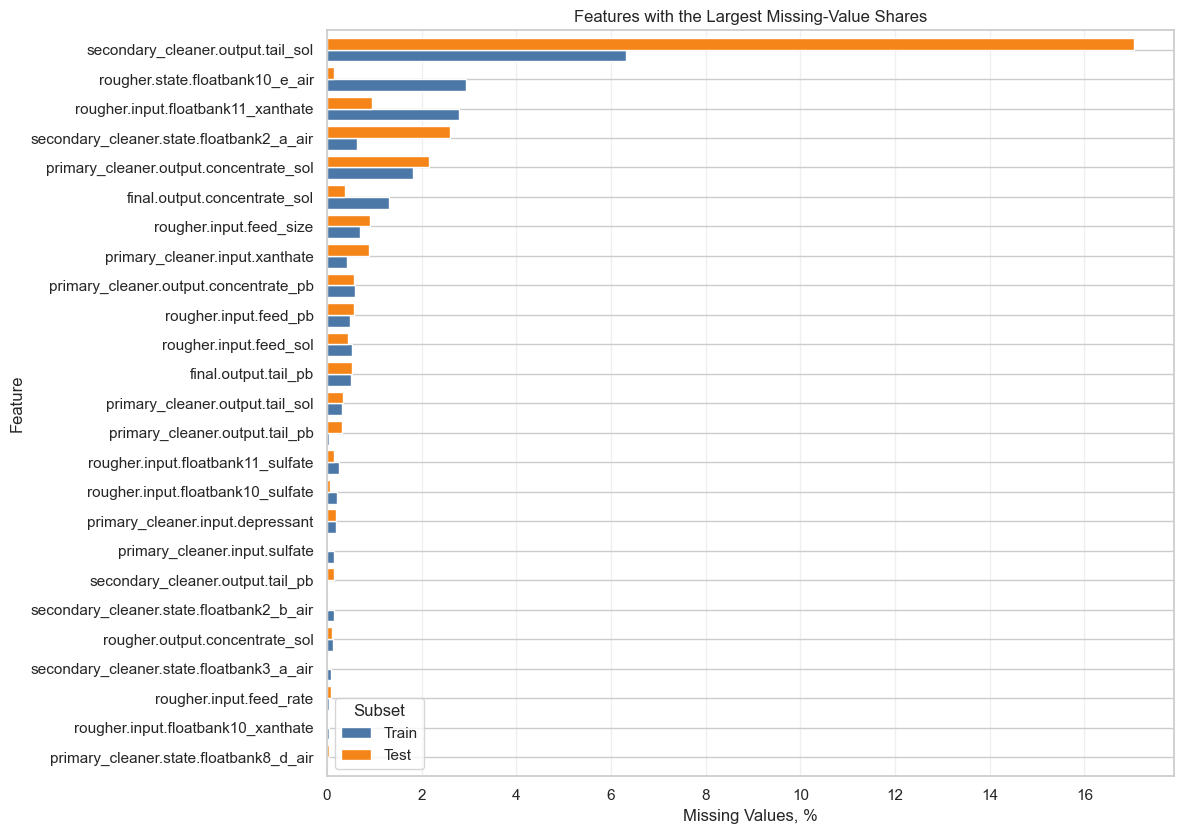

In [238]:
# Plot the features with the largest missing-value shares
missing_plot = missing_summary.loc[
    (missing_summary["%_train"] > 0) | (missing_summary["%_test"] > 0),
    ["%_train", "%_test"],
].copy()

missing_plot["max_missing"] = missing_plot.max(axis=1)
missing_plot = (
    missing_plot
    .nlargest(25, "max_missing")
    .sort_values("max_missing")
    .drop(columns="max_missing")
)

ax = missing_plot.rename(
    columns={"%_train": "Train", "%_test": "Test"}
).plot(
    kind="barh",
    figsize=(12, max(7, 0.34 * len(missing_plot))),
    color=["#4C78A8", "#F58518"],
    width=0.8,
)

ax.set_title("Features with the Largest Missing-Value Shares")
ax.set_xlabel("Missing Values, %")
ax.set_ylabel("Feature")
ax.legend(title="Subset")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

We calculate the number of rows containing at least one missing value for each DataFrame to select an appropriate treatment strategy:

- remove rows containing missing values; or
- impute the missing values.

In [239]:
# Filter the subsets
train_part = full_new[full_new['set'] == 'train']
test_part = full_new[full_new['set'] == 'test']

# Count the rows
train_len = len(train_part)
test_len = len(test_part)
full_len = len(full_new)

# Count rows containing at least one missing value
train_missing_rows = train_part.isnull().any(axis=1).sum()
test_missing_rows = test_part.isnull().any(axis=1).sum()
full_missing_rows = full_new.isnull().any(axis=1).sum()

# Calculate the percentage of rows with missing values
train_missing_pct = round(train_missing_rows / train_len * 100, 2)
test_missing_pct = round(test_missing_rows / test_len * 100, 2)
full_missing_pct = round(full_missing_rows / full_len * 100, 2)

display(f" Rows with missing values in train: {train_missing_rows} of {train_len} ({train_missing_pct}%)")
display(f" Rows with missing values in test:  {test_missing_rows} of {test_len} ({test_missing_pct}%)")
display(f" Rows with missing values in full:  {full_missing_rows} of {full_len} ({full_missing_pct}%)")

' Rows with missing values in train: 2242 of 14579 (15.38%)'

' Rows with missing values in test:  1103 of 4860 (22.7%)'

' Rows with missing values in full:  3345 of 19439 (17.21%)'

**Result**

Between **15% and 23% of rows in each DataFrame contain missing values**. Removing such a large proportion of observations would distort the datasets, so the missing values will be **imputed** in a later subsection.

#### Distribution Analysis

Let's examine the distributions of the columns in the complete dataset to understand their characteristics.  Create separate distribution plots for groups of related parameters.

We define a function to draw comparable histograms for feature groups supplied in dictionaries.

Every feature will receive its own panel. When a feature is present in the original test dataset, the training and test distributions will be overlaid using identical bin edges and axis limits. Output parameters, calculated features, and targets will be shown for the training period only because their values are not available when a prediction is made.

Isolated extreme values can compress the main part of a distribution and make it difficult to interpret. The panels will therefore display the pooled **0.5th-99.5th percentile** range and report the share outside that range. This restriction affects only the visualization: no observations are removed or changed.

In [240]:
def plot_group_distributions(
    train_data,
    grouped_features,
    test_data=None,
    lower_quantile=0.005,
    upper_quantile=0.995,
    bins=45,
):
    '''Plot one comparable distribution panel per numeric feature.'''

    palette = {"Train": "#4C78A8", "Test": "#F58518"}

    for group_name, features in grouped_features.items():
        numeric_features = [
            feature for feature in features
            if feature in train_data.columns
            and pd.api.types.is_numeric_dtype(train_data[feature])
        ]

        if not numeric_features:
            display(f"No numeric features are available for group '{group_name}'.")
            continue

        ncols = min(3, len(numeric_features))
        nrows = int(np.ceil(len(numeric_features) / ncols))
        fig, axes = plt.subplots(
            nrows,
            ncols,
            figsize=(5.2 * ncols, 3.8 * nrows),
            squeeze=False,
        )
        fig.suptitle(f"Feature Distributions: {group_name}", fontsize=15)

        for axis, feature in zip(axes.ravel(), numeric_features):
            series_by_subset = {
                "Train": pd.to_numeric(train_data[feature], errors="coerce")
                .replace([np.inf, -np.inf], np.nan)
                .dropna()
            }

            if test_data is not None and feature in test_data.columns:
                series_by_subset["Test"] = (
                    pd.to_numeric(test_data[feature], errors="coerce")
                    .replace([np.inf, -np.inf], np.nan)
                    .dropna()
                )

            pooled = pd.concat(series_by_subset.values(), ignore_index=True)
            lower = pooled.quantile(lower_quantile)
            upper = pooled.quantile(upper_quantile)

            if not np.isfinite(lower) or not np.isfinite(upper) or lower >= upper:
                lower, upper = pooled.min(), pooled.max()
            if lower >= upper:
                lower -= 0.5
                upper += 0.5

            common_bins = np.linspace(lower, upper, bins + 1)
            omitted_labels = []

            for subset_name, series in series_by_subset.items():
                visible = series.between(lower, upper, inclusive="both")
                omitted_share = 100 * (1 - visible.mean())
                omitted_labels.append(f"{subset_name}: {omitted_share:.1f}%")

                axis.hist(
                    series.loc[visible],
                    bins=common_bins,
                    density=True,
                    histtype="step",
                    linewidth=1.8,
                    color=palette[subset_name],
                    label=subset_name,
                )

            feature_parts = feature.split(".")
            stage_name = feature_parts[0].replace("_", " ")
            measurement_name = feature_parts[-1].replace("_", " ")
            short_name = f"{stage_name} - {measurement_name}"
            axis.set_title(short_name)
            axis.set_xlabel("Recorded Value")
            axis.set_ylabel("Density")
            axis.set_xlim(lower, upper)
            axis.legend()
            axis.grid(alpha=0.25)
            axis.text(
                0.02,
                0.97,
                "Outside displayed range - " + ", ".join(omitted_labels),
                transform=axis.transAxes,
                va="top",
                fontsize=7.5,
                bbox={"facecolor": "white", "alpha": 0.75, "edgecolor": "none"},
            )

        for axis in axes.ravel()[len(numeric_features):]:
            axis.set_visible(False)

        fig.text(
            0.5,
            0.01,
            "Common bins; pooled 0.5th-99.5th percentile display range. Data are not filtered.",
            ha="center",
            fontsize=9,
        )
        plt.tight_layout(rect=(0, 0.04, 1, 0.95))
        plt.show()

In [241]:
sns.set(style="whitegrid")

Plotte the feature-group distributions.

**Metal concentrations in the feed, rougher concentrate, primary-cleaner concentrate, and final concentrate**

In [242]:
# Dictionary of metal-concentration features

metal_concentrate_lists = {
    # Ore-feed parameters
    'Feed: Metal Concentrations': [
        'rougher.input.feed_au',
        'rougher.input.feed_ag',
        'rougher.input.feed_pb',
        'rougher.input.feed_sol'
    ],

  
    #  Concentrate after the rougher stage
    'Rougher: Concentrate after Flotation': [
        'rougher.output.concentrate_au',
        'rougher.output.concentrate_ag',
        'rougher.output.concentrate_pb',
        'rougher.output.concentrate_sol'
    ],

    #  Concentrate after primary purification
    'Primary Cleaner: Concentrate after Primary Purification': [
        'primary_cleaner.output.concentrate_au',
        'primary_cleaner.output.concentrate_ag',
        'primary_cleaner.output.concentrate_pb',
        'primary_cleaner.output.concentrate_sol'

    ],
 

    # Final output parameters
    'Final Output: Concentrate after Secondary Purification': [
        'final.output.concentrate_au',
        'final.output.concentrate_ag',
        'final.output.concentrate_pb',
        'final.output.concentrate_sol'

    ]
}

In [243]:
full_new.columns

Index(['date', 'rougher.input.feed_au', 'rougher.input.feed_ag',
       'rougher.input.feed_pb', 'rougher.input.feed_sol',
       'rougher.input.feed_rate', 'rougher.input.feed_size',
       'rougher.input.floatbank10_sulfate',
       'rougher.input.floatbank10_xanthate', 'rougher.state.floatbank10_a_air',
       'rougher.state.floatbank10_a_level', 'rougher.state.floatbank10_b_air',
       'rougher.state.floatbank10_b_level', 'rougher.state.floatbank10_c_air',
       'rougher.state.floatbank10_c_level', 'rougher.state.floatbank10_d_air',
       'rougher.state.floatbank10_d_level', 'rougher.state.floatbank10_e_air',
       'rougher.state.floatbank10_e_level', 'rougher.state.floatbank10_f_air',
       'rougher.state.floatbank10_f_level',
       'rougher.input.floatbank11_sulfate',
       'rougher.input.floatbank11_xanthate',
       'rougher.calculation.sulfate_to_au_concentrate',
       'rougher.calculation.floatbank10_sulfate_to_au_feed',
       'rougher.calculation.floatbank11_sulfate

In [244]:
full_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19439 entries, 0 to 19438
Data columns (total 88 columns):
 #   Column                                              Non-Null Count  Dtype         
---  ------                                              --------------  -----         
 0   date                                                19439 non-null  datetime64[ns]
 1   rougher.input.feed_au                               19439 non-null  float64       
 2   rougher.input.feed_ag                               19439 non-null  float64       
 3   rougher.input.feed_pb                               19339 non-null  float64       
 4   rougher.input.feed_sol                              19340 non-null  float64       
 5   rougher.input.feed_rate                             19428 non-null  float64       
 6   rougher.input.feed_size                             19294 non-null  float64       
 7   rougher.input.floatbank10_sulfate                   19405 non-null  float64       
 8   roughe

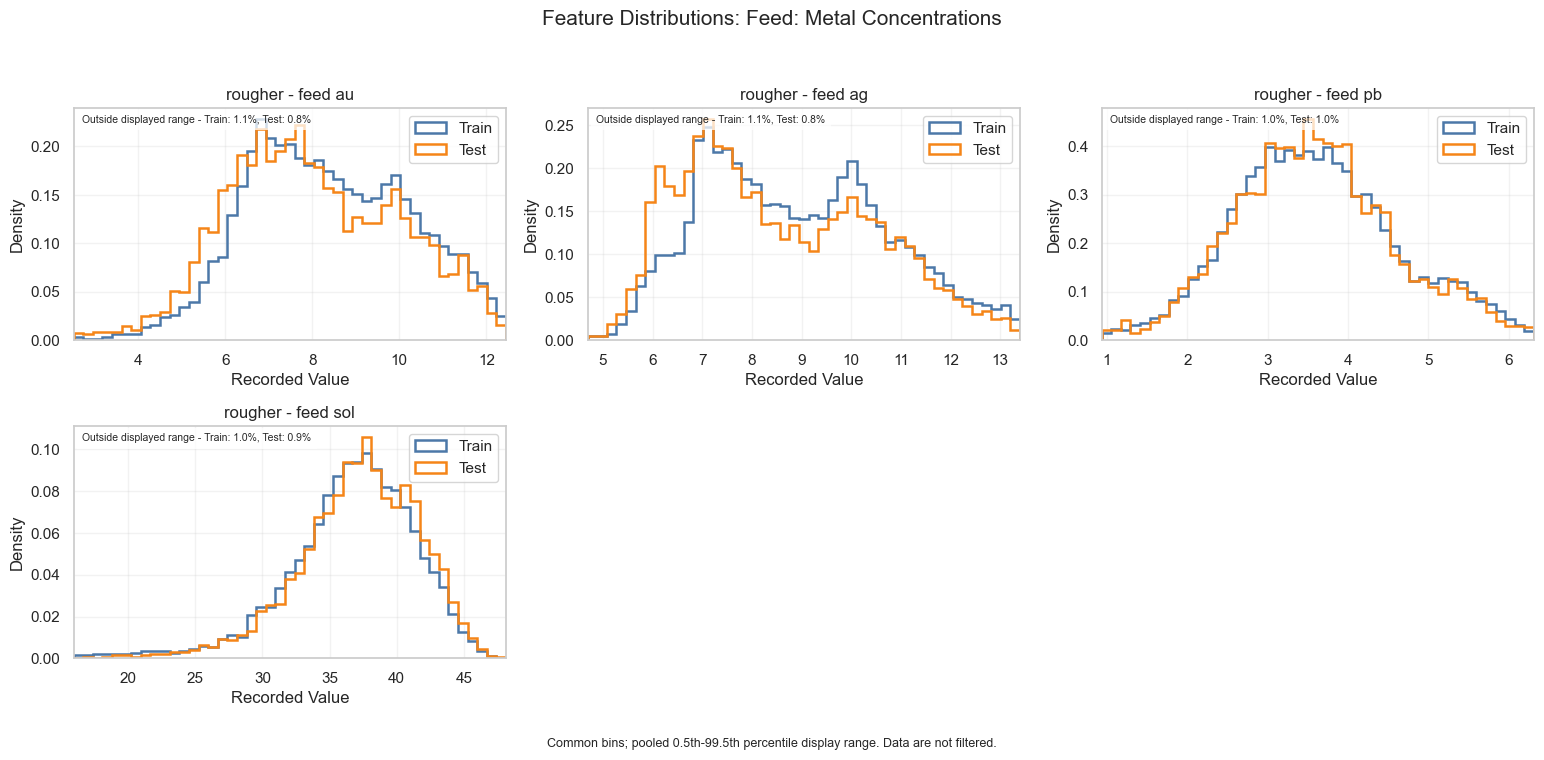

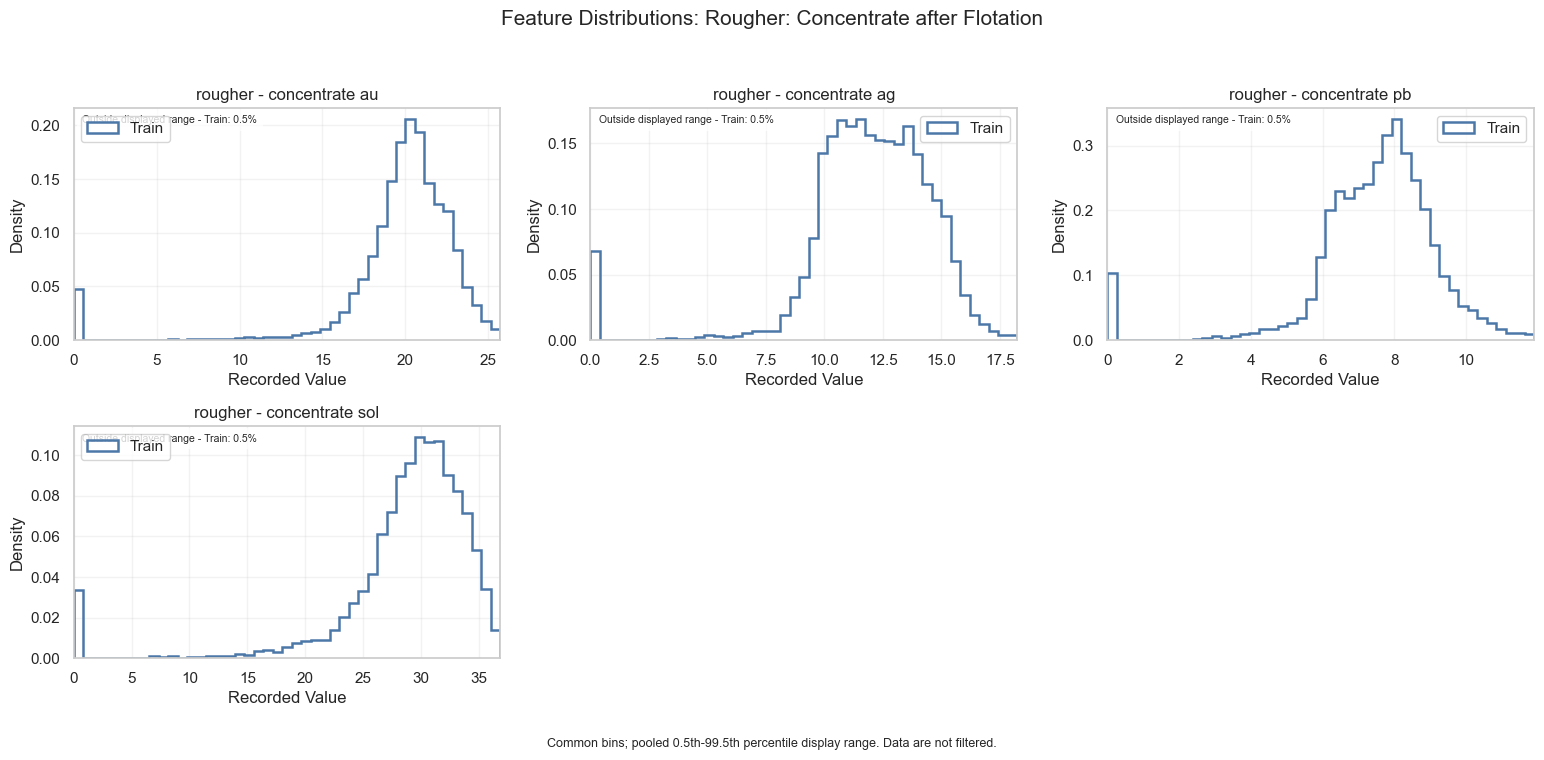

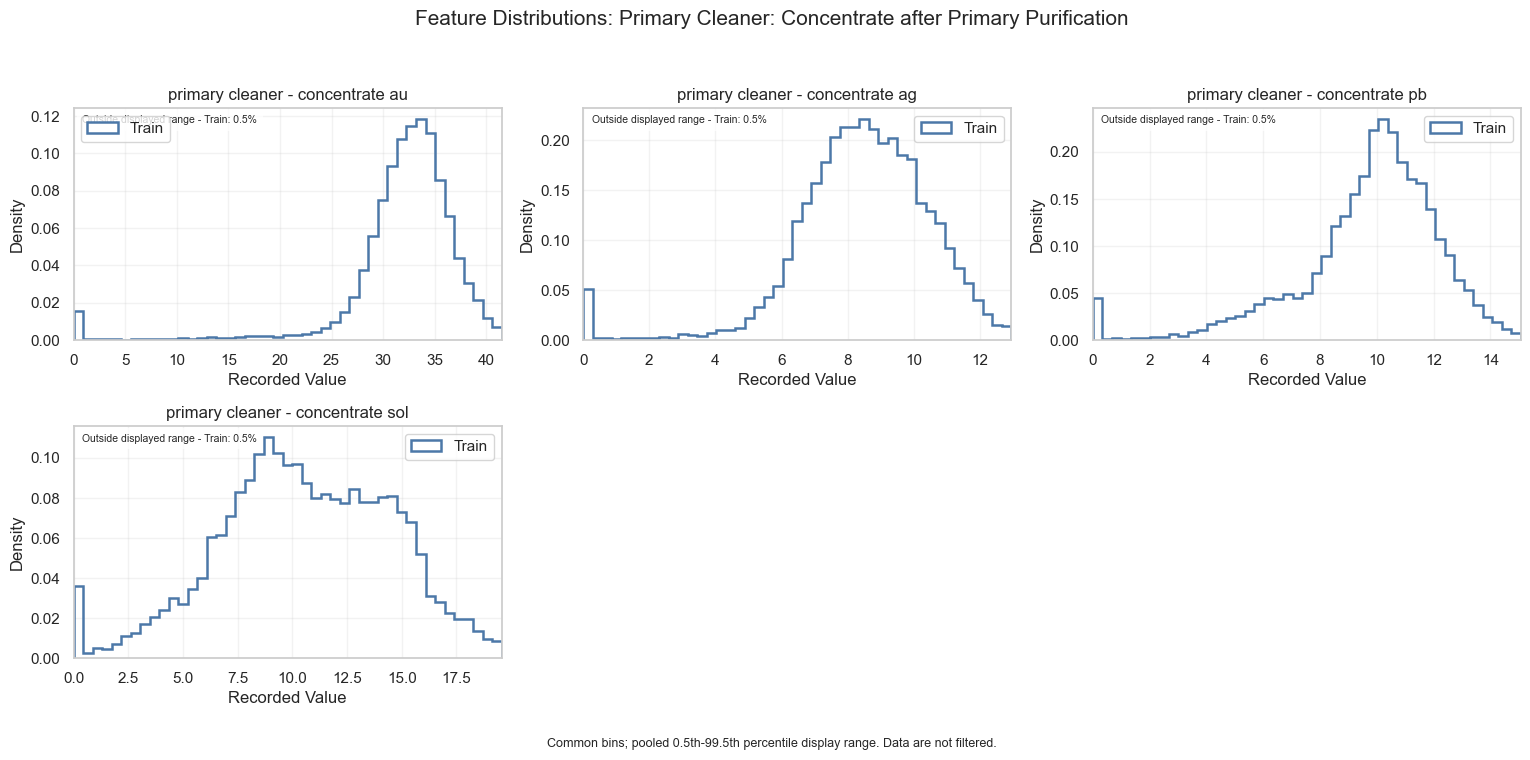

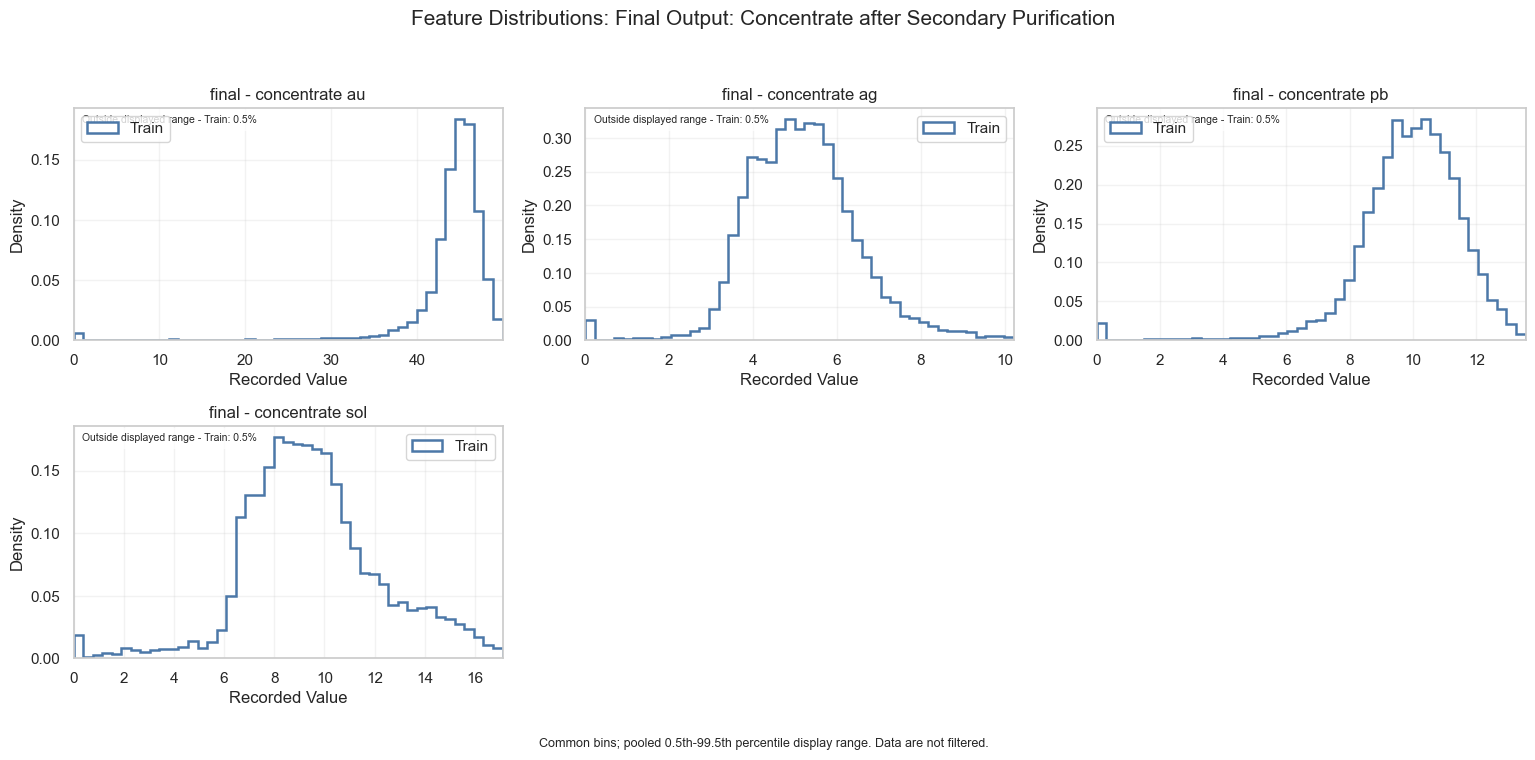

In [245]:
plot_group_distributions(train_new, metal_concentrate_lists, test_new)

**Findings:**

- The feed-metal features occupy broadly overlapping ranges in the training and test periods.
- Gold and silver show visible differences in the relative heights of their modes, while lead and solids are more closely aligned.
- Because the test set represents a later chronological period, these differences should be treated as possible univariate distribution shift rather than evidence that the two subsets are identically distributed.
- Output concentrations are displayed for the training set only because the corresponding values are unavailable before process completion.
- Several distributions are skewed or multimodal and contain long tails rather than being strictly normal.
- Peaks near zero represent recorded process values rather than missing values (`NaN`). They may correspond to shutdowns, unstable operating periods, or measurement anomalies and will be investigated separately.

In [246]:
metal_concentrate = full_new[metal_concentrate_lists['Feed: Metal Concentrations']]
neg_val = metal_concentrate[metal_concentrate < 0].any()
neg_val

rougher.input.feed_au     False
rougher.input.feed_ag     False
rougher.input.feed_pb     False
rougher.input.feed_sol    False
dtype: bool

**Residual metal concentrations in the tailings after flotation, primary purification, secondary purification, and in the final output**

In [247]:
# Dictionary of metal concentrations in the tailings

tail_lists = {

    # Rougher tailings
    'Rougher: Tailings after Flotation': [
        'rougher.output.tail_au',
        'rougher.output.tail_ag',
        'rougher.output.tail_pb',
        'rougher.output.tail_sol'
    ],

    # Primary-cleaner tailings
    'Primary Cleaner: Tailings after Primary Purification': [
        'primary_cleaner.output.tail_au',
        'primary_cleaner.output.tail_ag',
        'primary_cleaner.output.tail_pb',
        'primary_cleaner.output.tail_sol'
    ],

    # Secondary-cleaner tailings
    'Secondary Cleaner: Tailings after Secondary Purification': [
        'secondary_cleaner.output.tail_au',
        'secondary_cleaner.output.tail_ag',
        'secondary_cleaner.output.tail_pb',
        'secondary_cleaner.output.tail_sol'
    ],

    # Final-output tailings
    'Final Output: Tailings': [
        'final.output.tail_au',
        'final.output.tail_ag',
        'final.output.tail_pb',
        'final.output.tail_sol'
    ]
}

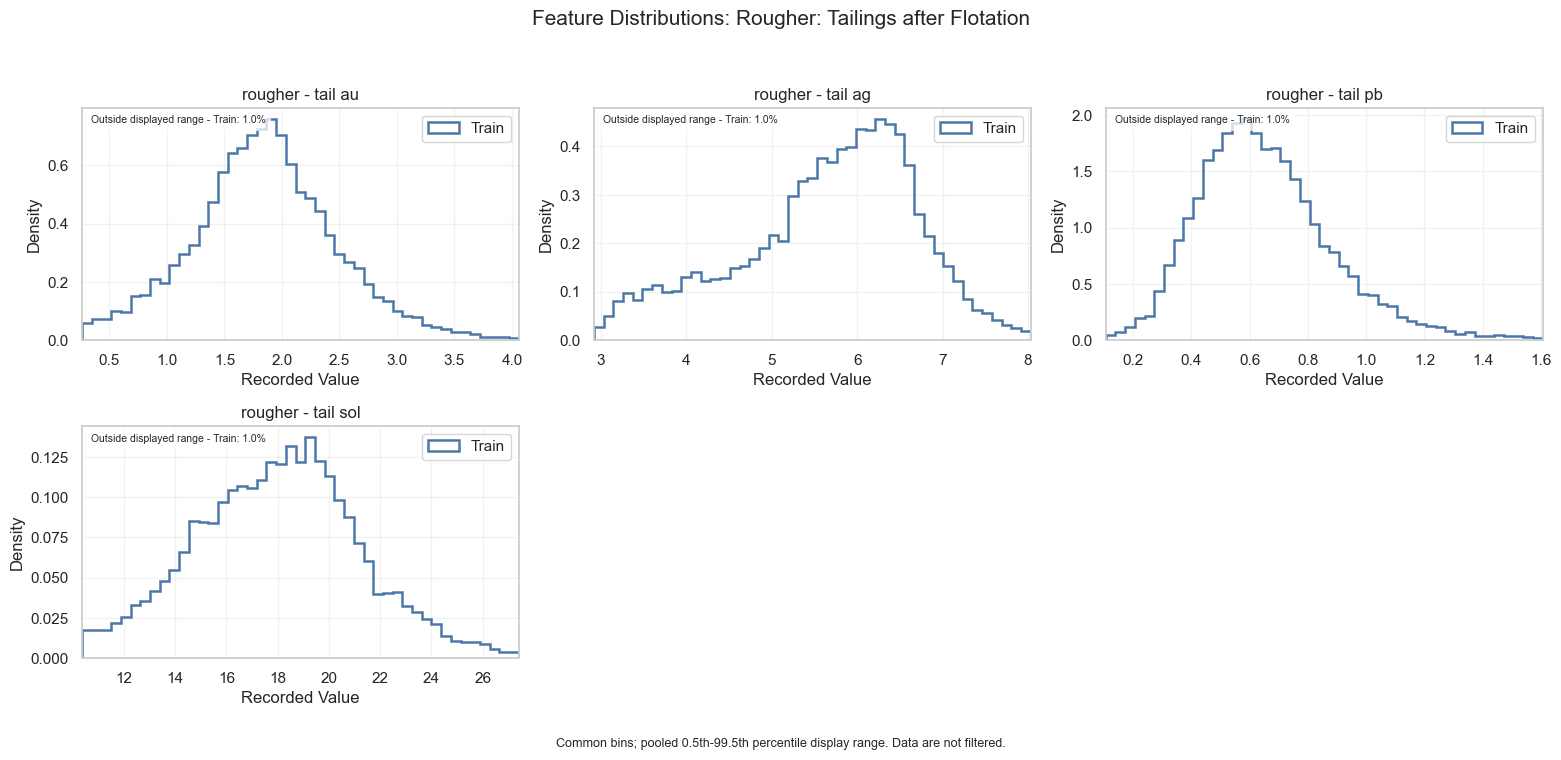

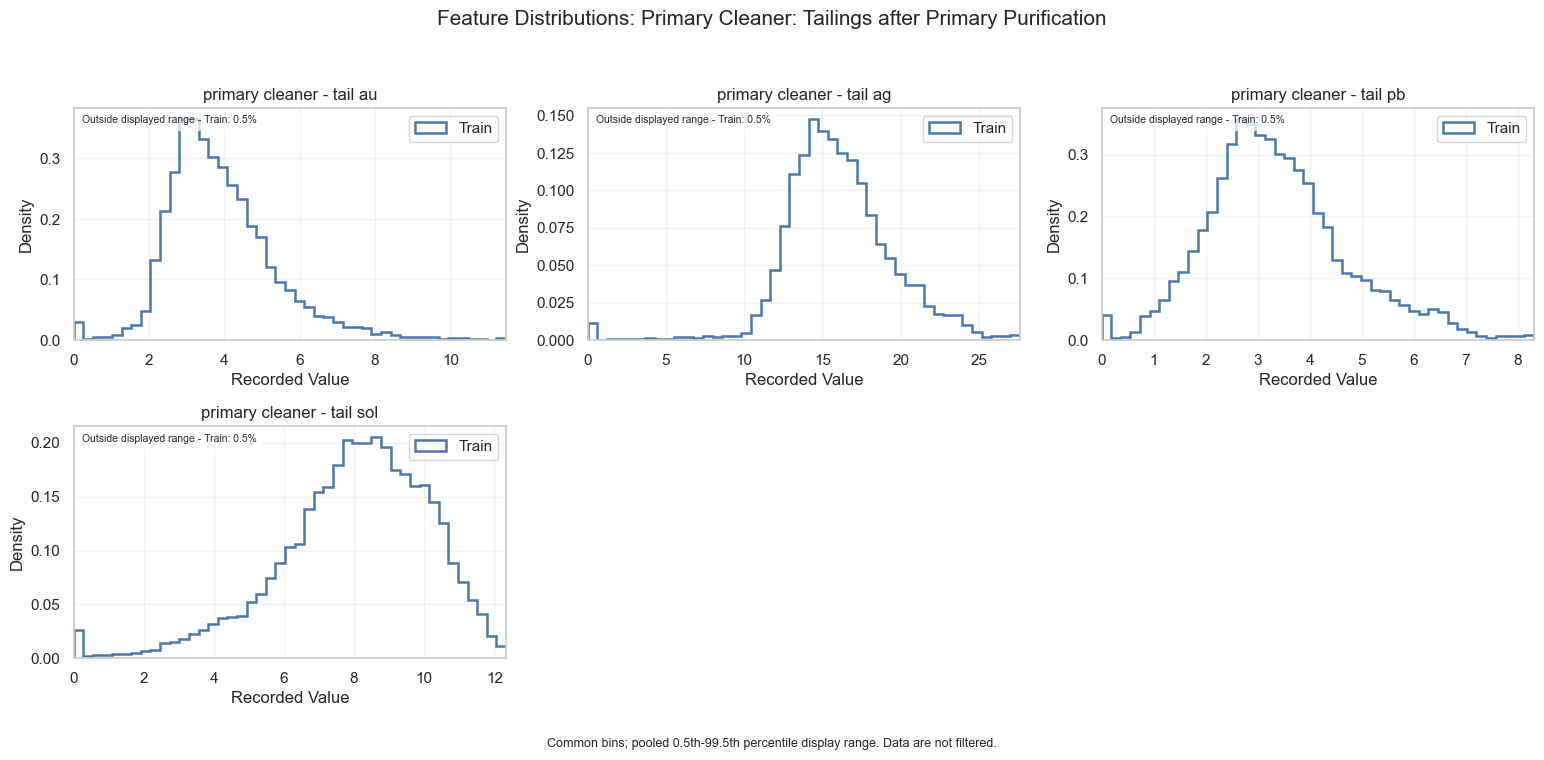

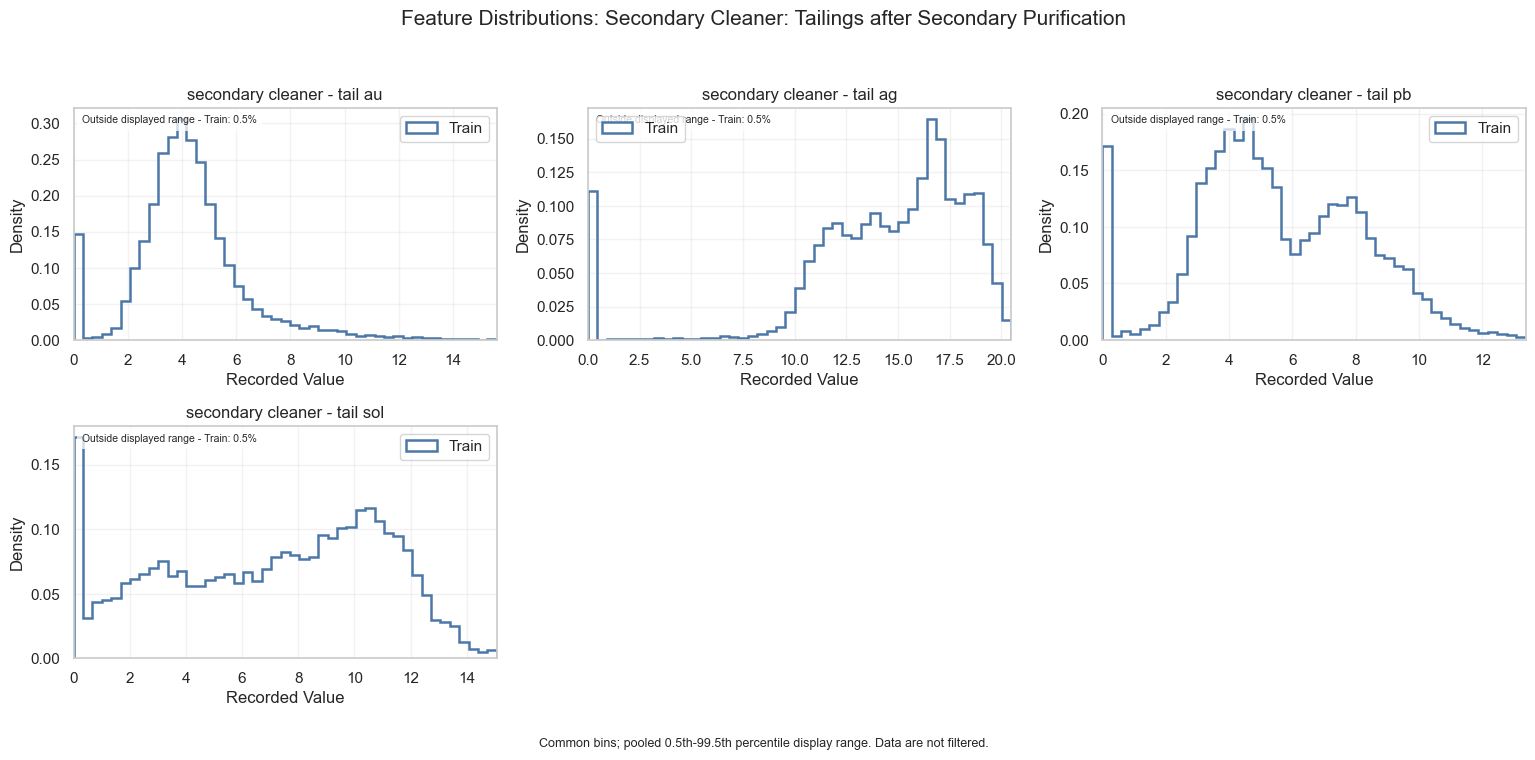

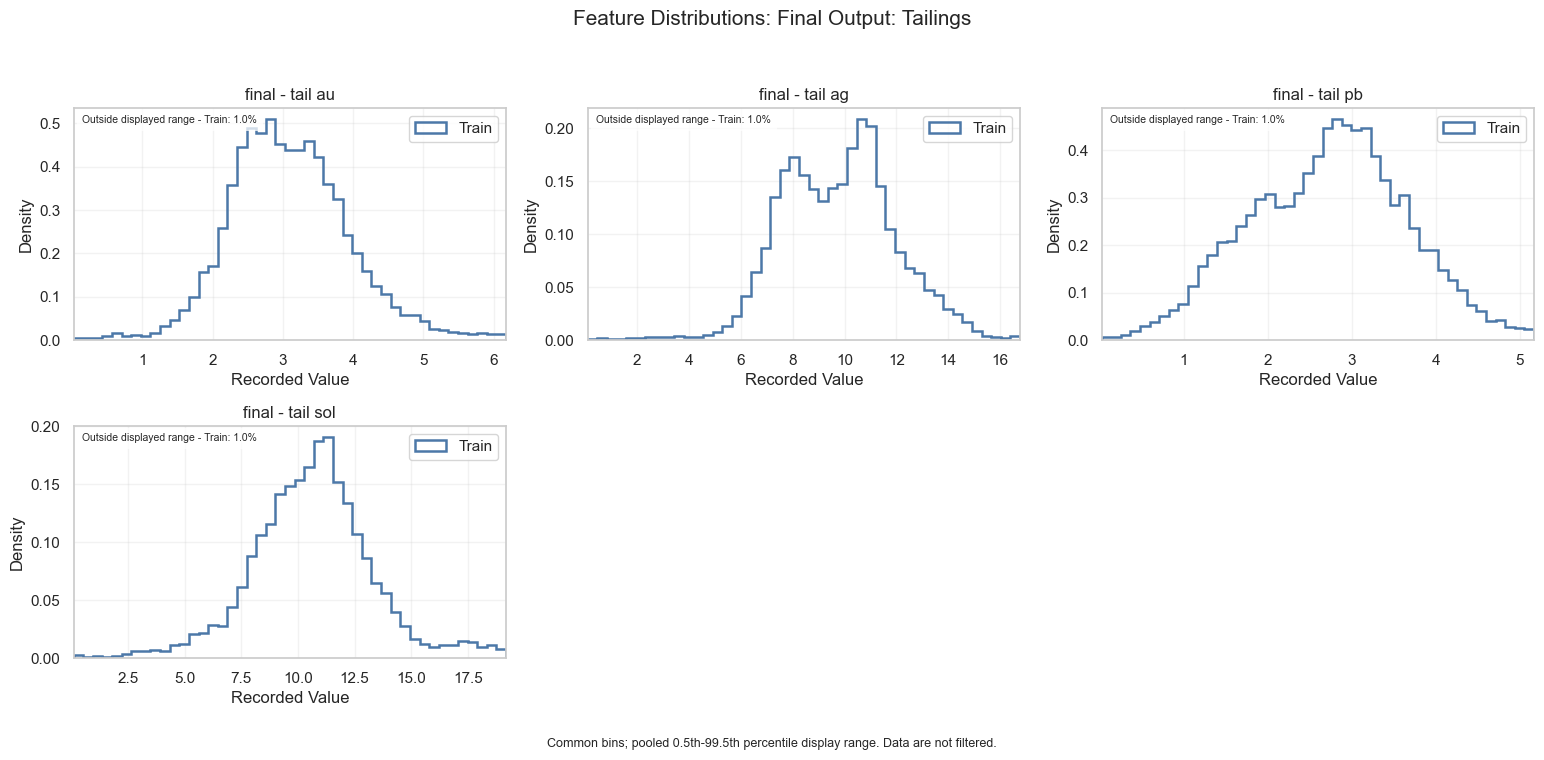

In [248]:
plot_group_distributions(train_new, tail_lists, test_new)

**Tailings** are the residual materials remaining after each processing stage. Their distributions help quantify metal losses and assess purification efficiency.

**Findings:**

- Tail concentrations are examined for the training period only because they are output parameters unavailable at prediction time.
- Most distributions are skewed and contain long tails rather than being strictly normal.
- Negative and near-zero values may indicate measurement anomalies or unusual operating periods. Their origin cannot be established from the supplied data alone, so they require process-aware interpretation.

**Calculated indicators: sulphate-to-gold and gold-to-lead ratios, and gold recovery rates**

In [249]:
# Dictionary of calculated indicators

calculation_lists = {

    # Calculated indicators at the rougher stage
    'Rougher: Sulphate-to-Gold Ratio in the Feed': [
        'rougher.calculation.floatbank10_sulfate_to_au_feed',
        'rougher.calculation.floatbank11_sulfate_to_au_feed'

    ],
    
     'Rougher: Sulphate-to-Gold Ratio in the Concentrate': [
        'rougher.calculation.sulfate_to_au_concentrate'

    ],

    'Rougher: Gold-to-Lead Ratio in the Concentrate': [
        'rougher.calculation.au_pb_ratio'
    ],


    #  Recovery rates
    'Rougher and Final Output: Gold Recovery Rates': [

        'rougher.output.recovery',
        'final.output.recovery'

    ]
}

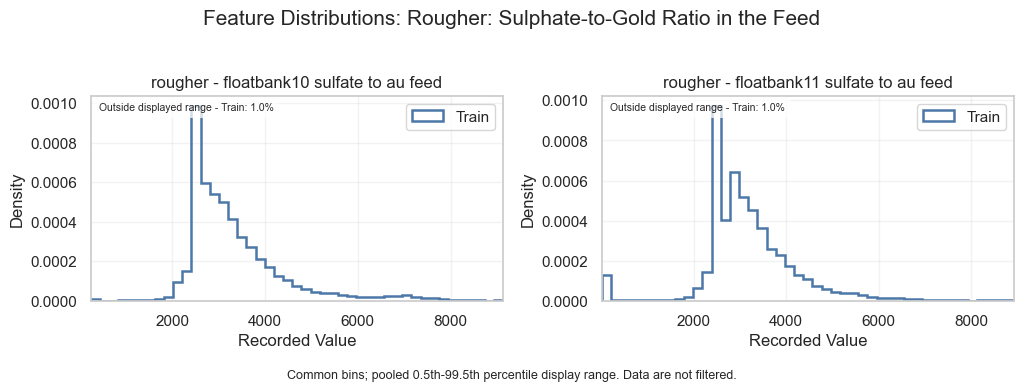

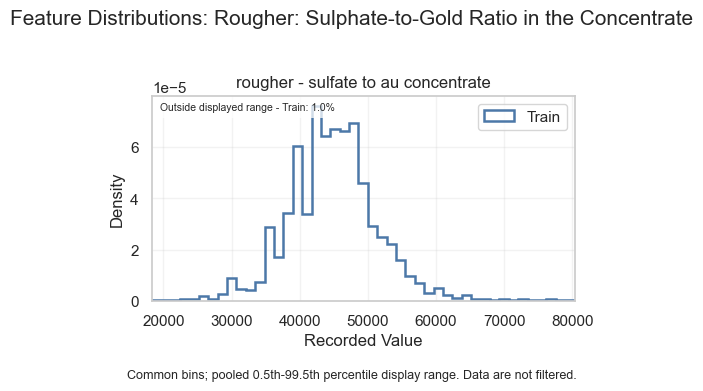

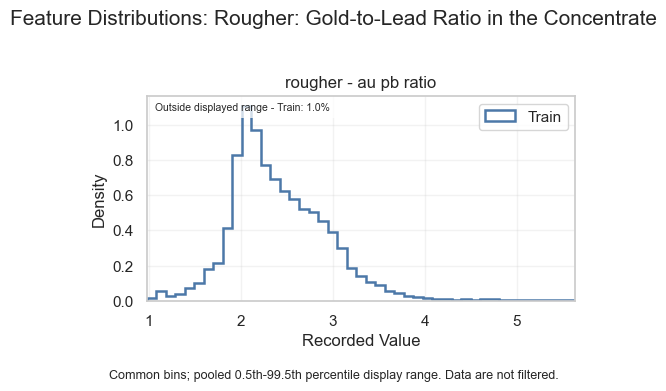

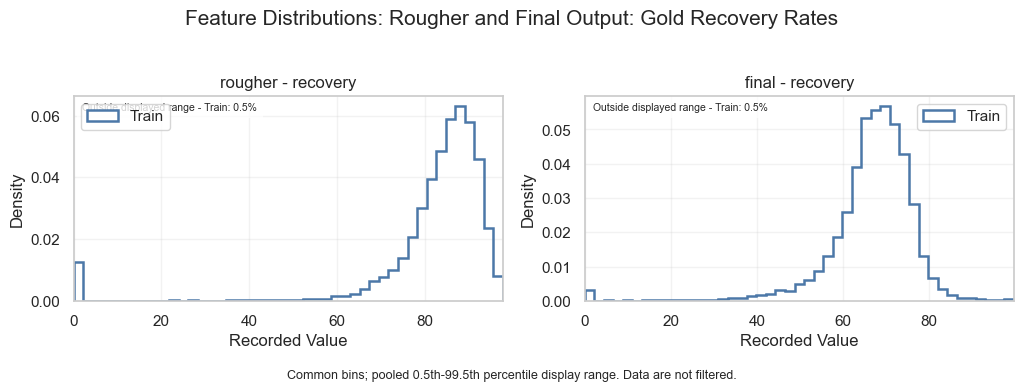

In [250]:
plot_group_distributions(train_new, calculation_lists, test_new)

**Findings:**

- Calculated indicators and recovery targets are examined for the training period only.
- The recovery rates are concentrated within a relatively narrow range.
- Several ratio features contain extreme values that make an unrestricted density plot difficult to interpret. The revised panels therefore use common histograms and display the central 99% range explicitly.
- Negative or near-zero ratios are physically questionable. However, these calculated features are unavailable at prediction time and will not be used for model training.

**Reagents**

In [251]:
# Dictionary of reagent features


reagent_lists = {

    # Reagents at the rougher stage
    'Rougher: Sulphate Reagent during Flotation': [
        'rougher.input.floatbank10_sulfate',
        'rougher.input.floatbank11_sulfate'


    ],

        # Reagents at the rougher stage
    'Rougher: Xanthate Reagent during Flotation': [
        'rougher.input.floatbank10_xanthate',
        'rougher.input.floatbank11_xanthate',

    ],

    # Primary-cleaner parameters
    'Primary Cleaner: Xanthate and Depressant during Primary Purification': [
        'primary_cleaner.input.depressant',
        'primary_cleaner.input.xanthate'

    ],
    
    'Primary Cleaner: Sulphate during Primary Purification': [
        'primary_cleaner.input.sulfate',
        

    ]

}

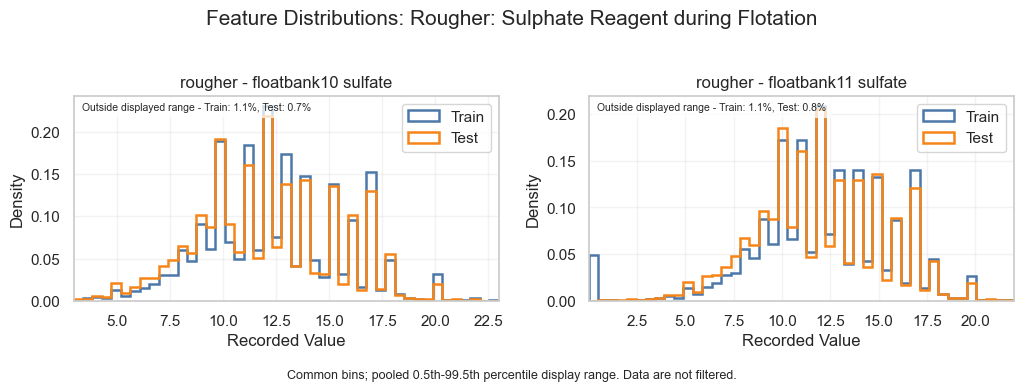

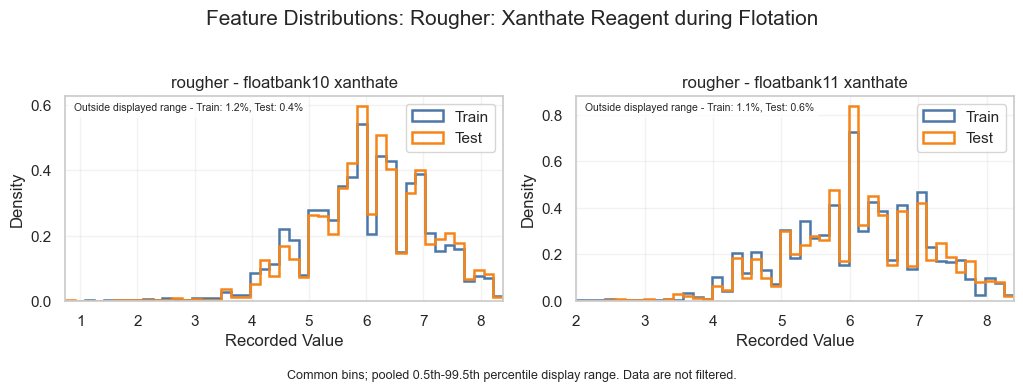

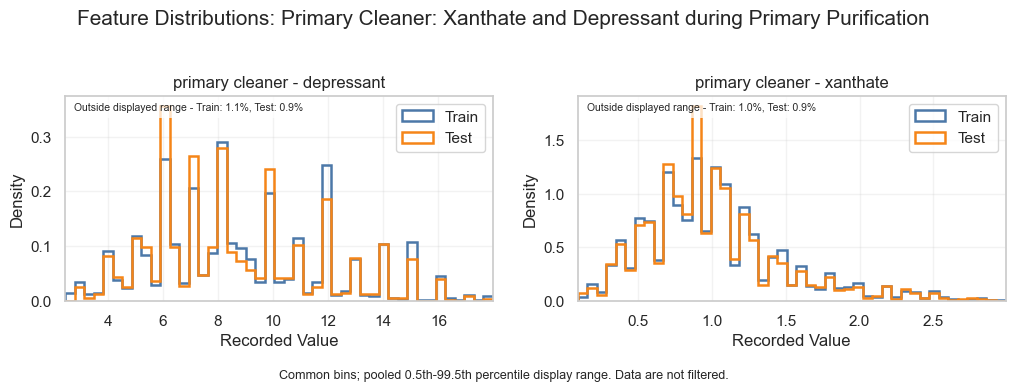

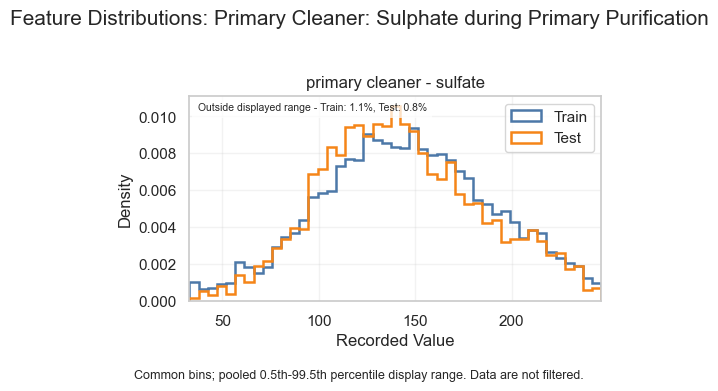

In [252]:
plot_group_distributions(train_new, reagent_lists, test_new)

**Findings:**

- The reagent-input distributions in `train` and `test` are broadly similar, although small differences are visible in several ranges.
- The distributions are frequently skewed or multimodal, which is plausible because the variables represent different process-control settings.
- Several features contain long tails. These observations should not be removed automatically because they may represent legitimate operating regimes rather than data errors.

**Feed Characteristics**

In [253]:
# Dictionary of feed characteristics

feed_lists = {

    # Feed characteristics
    'Feed: Flow Rate': [
        'rougher.input.feed_rate'

    ],
    
    'Feed: Particle Size before Flotation': [
        'rougher.input.feed_size'

    ],

    'Feed: Particle Size before Primary Purification': [
        'primary_cleaner.input.feed_size'
    ]
}

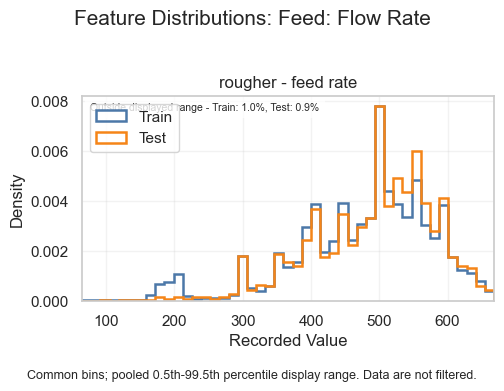

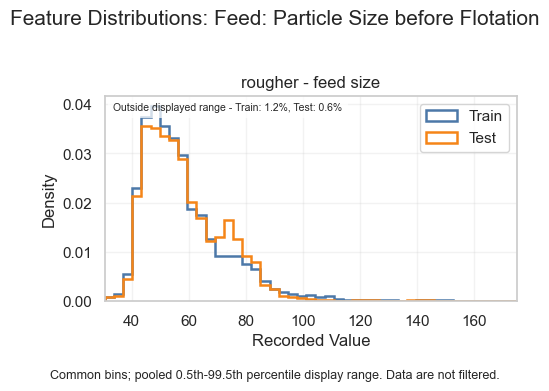

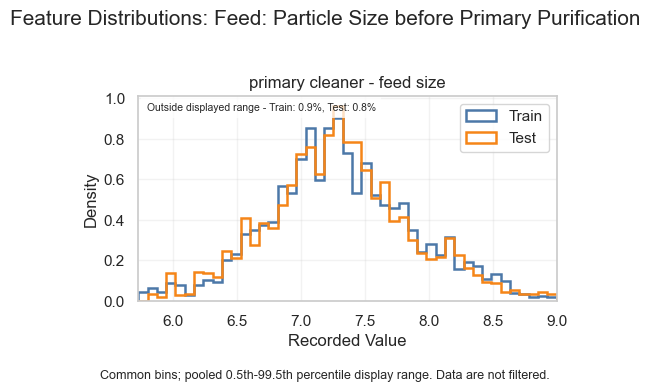

In [254]:
plot_group_distributions(train_new, feed_lists, test_new)

**Findings:**

- The feed-rate and particle-size distributions are broadly similar in the training and test periods.
- Some long tails and isolated extreme values are present.
- A more detailed comparison of the two feed-size features will be performed in the data-analysis section using both central-range histograms and full-range cumulative distributions.

**Technical Process Parameters**

In [255]:
floatbank_lists = {


    #  Technical parameters at the rougher stage
    'Rougher: Air Volume in Flotation Cells': [
        'rougher.state.floatbank10_a_air',
        'rougher.state.floatbank10_b_air',
        'rougher.state.floatbank10_c_air',
        'rougher.state.floatbank10_d_air',
        'rougher.state.floatbank10_e_air',
        'rougher.state.floatbank10_f_air'

    ],

   
    #  Primary-cleaner parameters
      'Primary Cleaner: Air Volume in Cells': [
        'primary_cleaner.state.floatbank8_a_air',
        'primary_cleaner.state.floatbank8_b_air',
        'primary_cleaner.state.floatbank8_c_air',
        'primary_cleaner.state.floatbank8_d_air'

    ],


    #  Secondary Cleaner
    'Secondary Cleaner: Air Volume in Cells': [
        'secondary_cleaner.state.floatbank2_a_air',
        'secondary_cleaner.state.floatbank2_b_air',
        'secondary_cleaner.state.floatbank3_a_air',
        'secondary_cleaner.state.floatbank3_b_air',
        'secondary_cleaner.state.floatbank4_a_air',
        'secondary_cleaner.state.floatbank4_b_air',
        'secondary_cleaner.state.floatbank5_a_air',
        'secondary_cleaner.state.floatbank5_b_air',
        'secondary_cleaner.state.floatbank6_a_air'

    ],
    
        #  Technical parameters at the rougher stage
    'Rougher: Liquid Level in Flotation Cells': [
        'rougher.state.floatbank10_a_level',
        'rougher.state.floatbank10_b_level',
        'rougher.state.floatbank10_c_level',
        'rougher.state.floatbank10_d_level',
        'rougher.state.floatbank10_e_level',
        'rougher.state.floatbank10_f_level'

    ],

   
    #  Primary-cleaner parameters
      'Primary Cleaner: Liquid Level in Cells': [
        'primary_cleaner.state.floatbank8_a_level',
        'primary_cleaner.state.floatbank8_b_level',
        'primary_cleaner.state.floatbank8_c_level',
        'primary_cleaner.state.floatbank8_d_level'

    ],


    #  Secondary Cleaner
    'Secondary Cleaner: Liquid Level in Cells': [
        'secondary_cleaner.state.floatbank2_a_level',
        'secondary_cleaner.state.floatbank2_b_level',
        'secondary_cleaner.state.floatbank3_a_level',
        'secondary_cleaner.state.floatbank3_b_level',
        'secondary_cleaner.state.floatbank4_a_level',
        'secondary_cleaner.state.floatbank4_b_level',
        'secondary_cleaner.state.floatbank5_a_level',
        'secondary_cleaner.state.floatbank5_b_level',
        'secondary_cleaner.state.floatbank6_a_level'

    ]
}


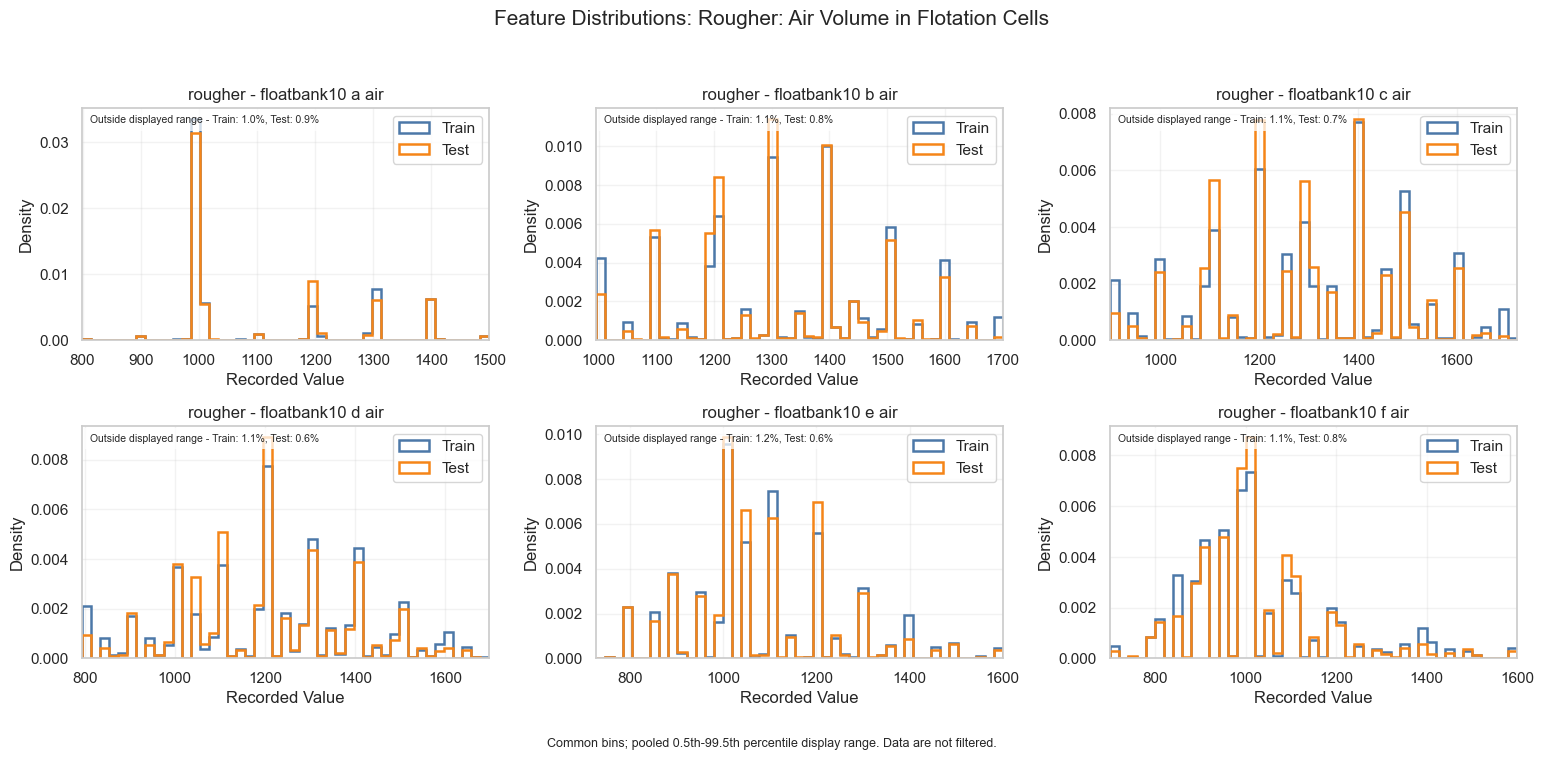

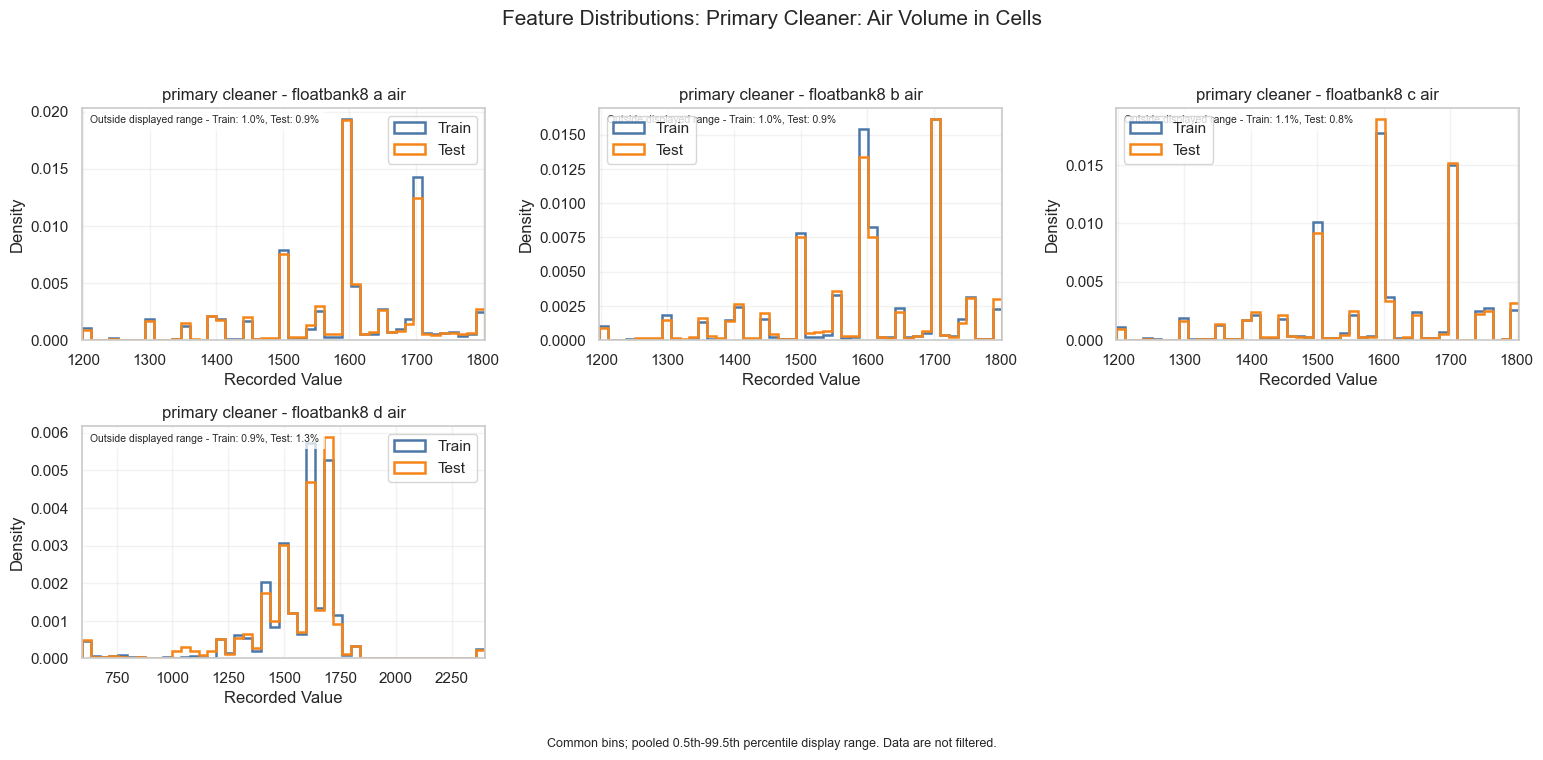

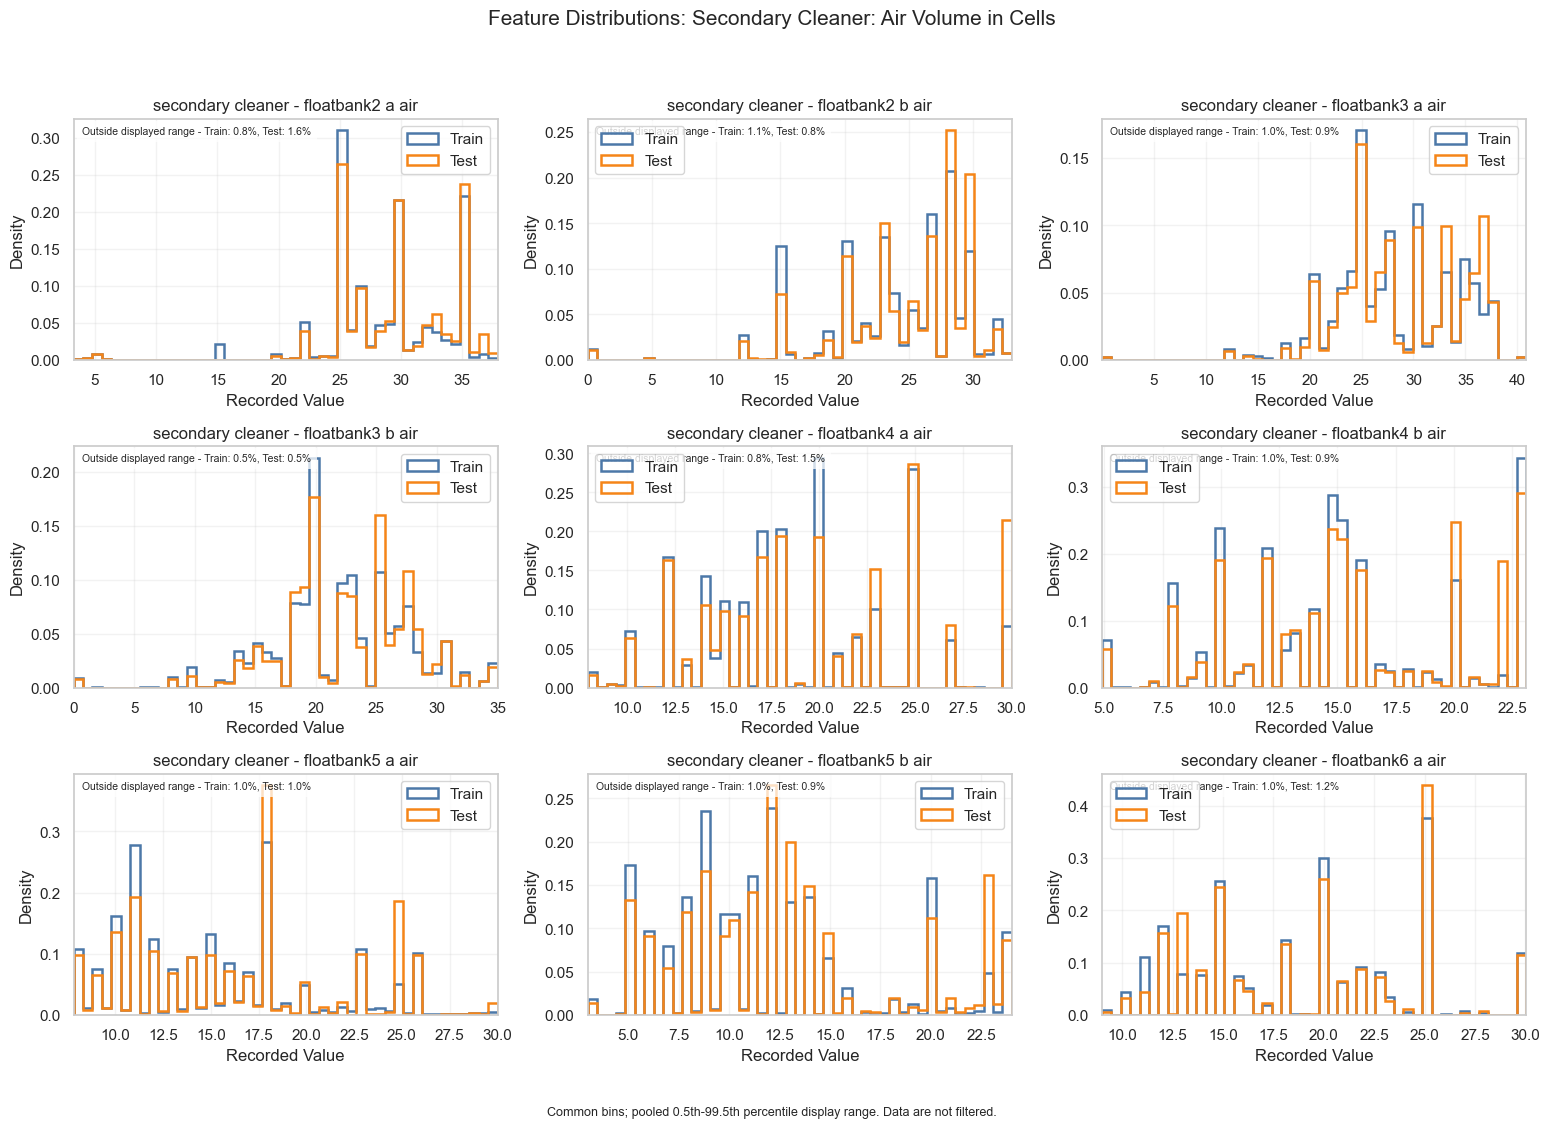

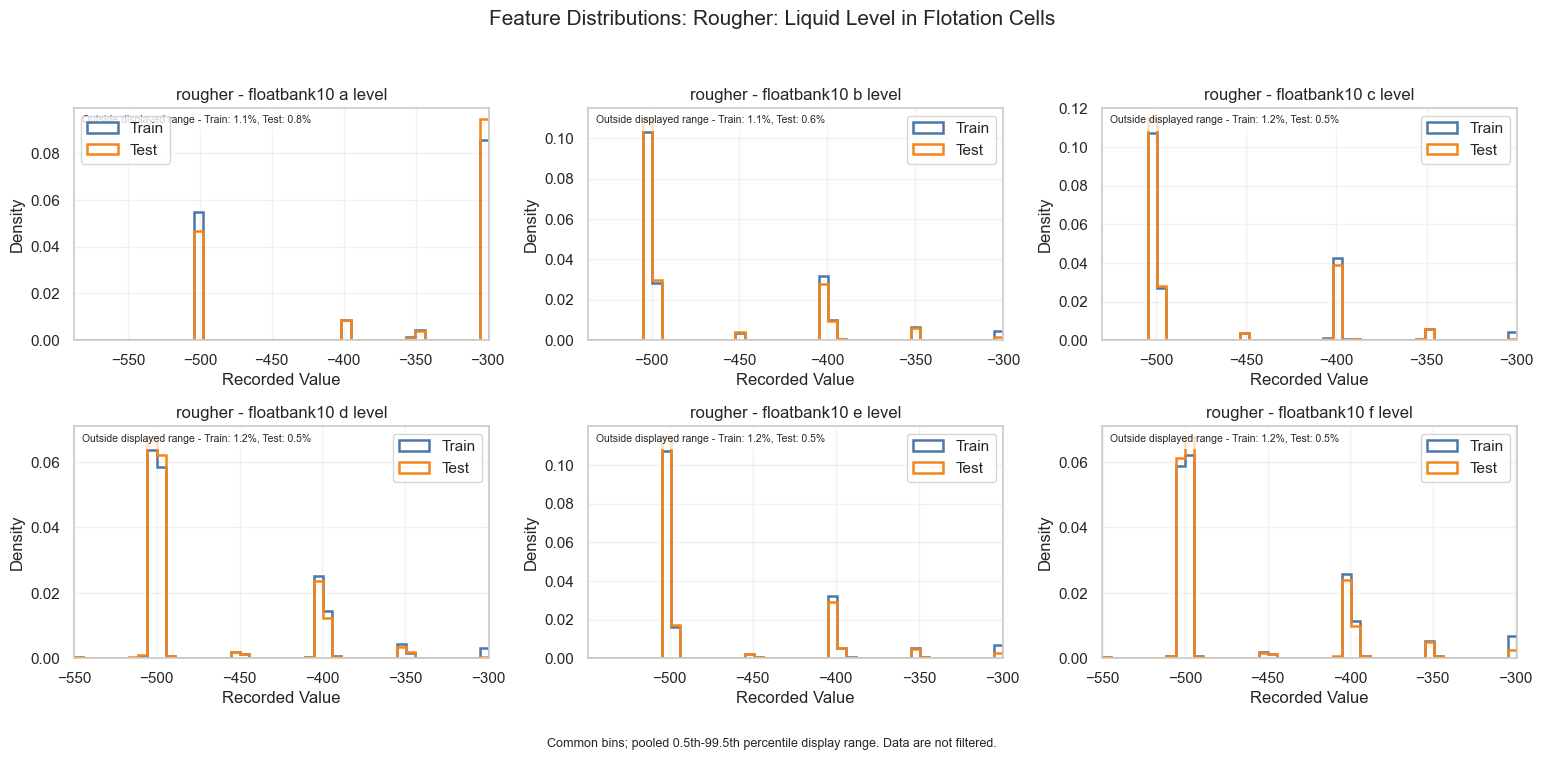

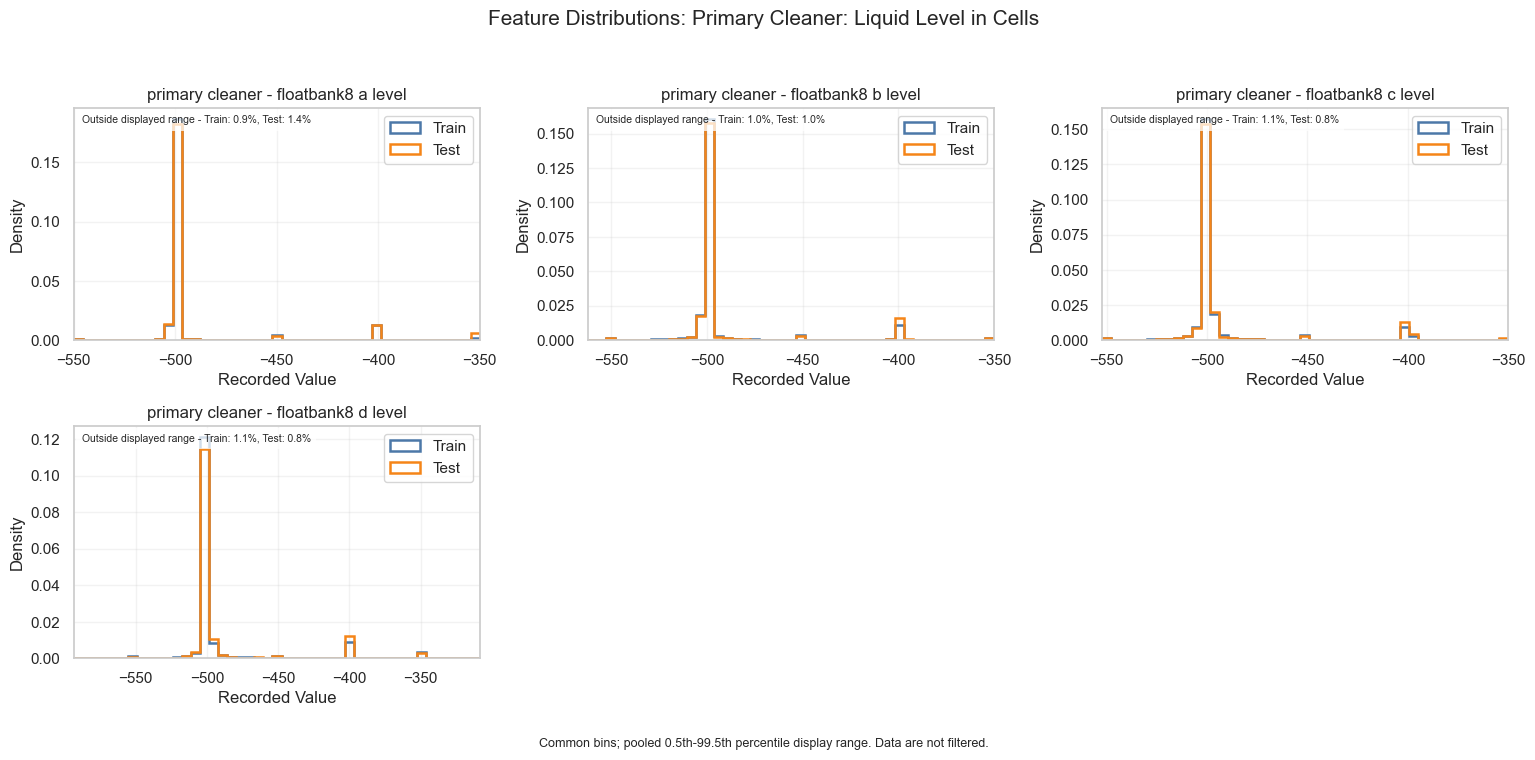

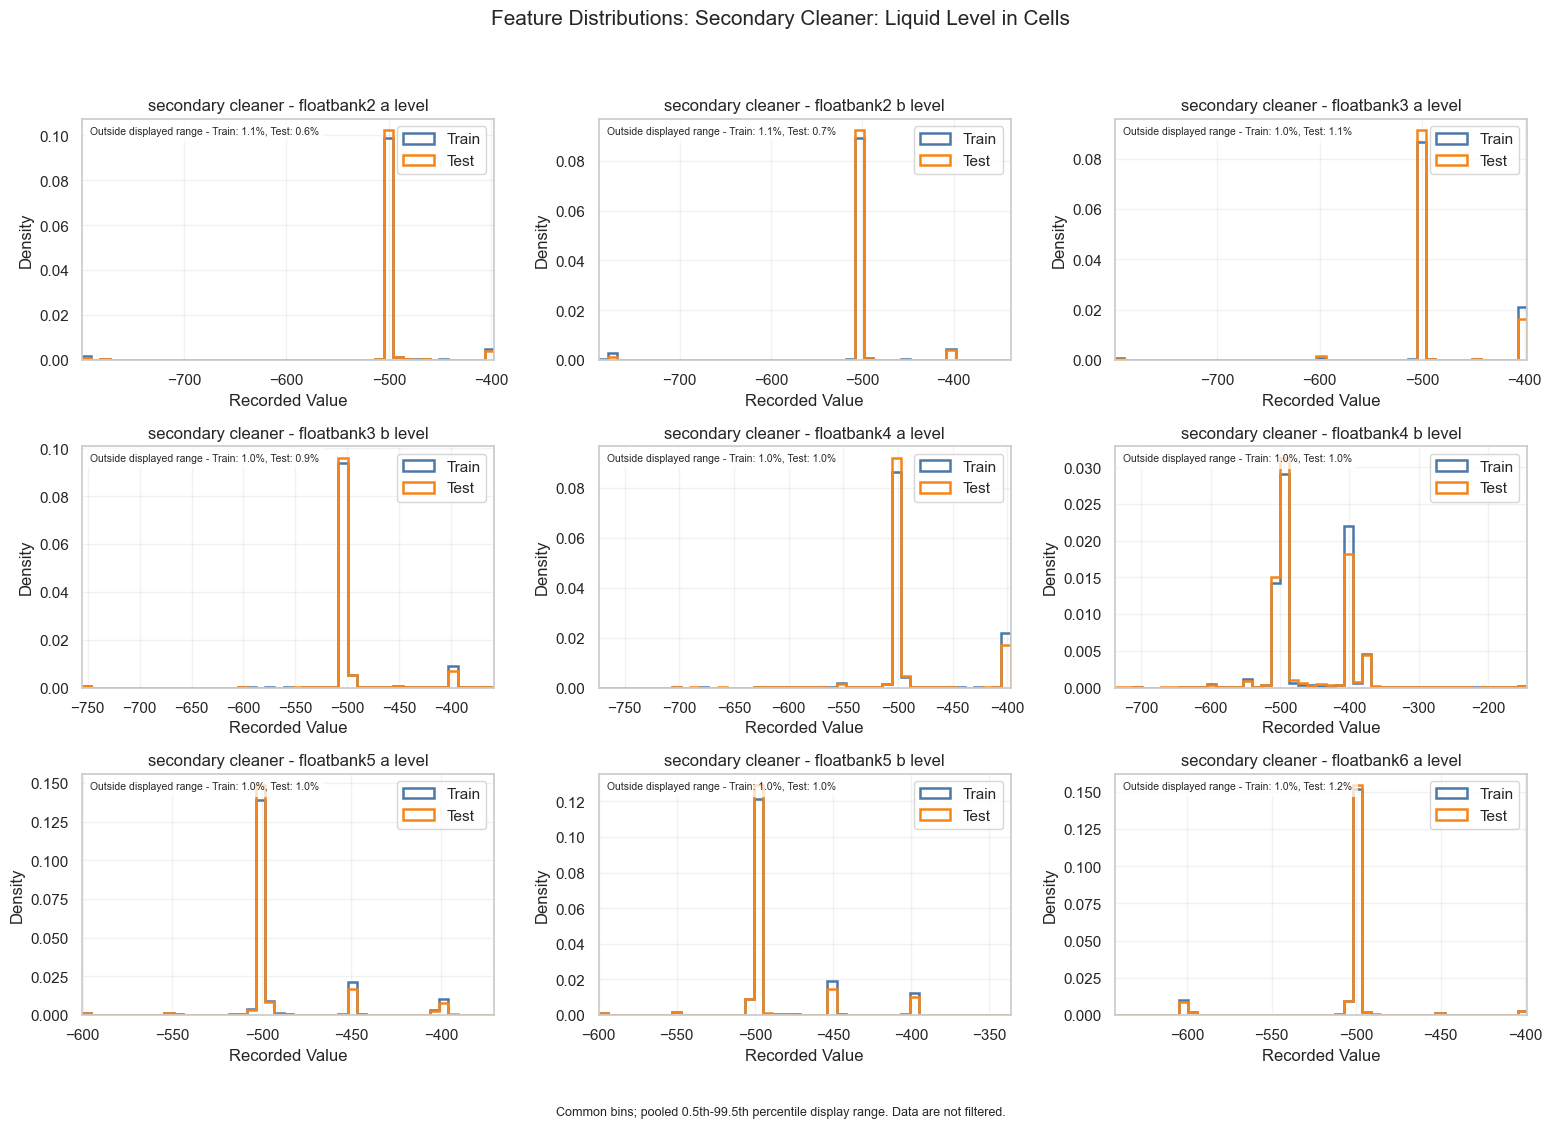

In [256]:
plot_group_distributions(train_new, floatbank_lists, test_new)

**Findings:**

- Most air-volume and liquid-level features occupy overlapping ranges in `train` and `test`, although the positions and relative heights of several modes differ between the chronological periods.
- Multimodal distributions are plausible because these variables may describe distinct equipment operating levels.
- Negative liquid-level values occur systematically and are therefore more likely to reflect the measurement scale than isolated data-entry errors.
- The visible changes in modal structure support the need for chronological validation and should be monitored as possible operating-regime shift.

**Overall Findings:**

- Most input and state parameters available at prediction time occupy overlapping ranges in the chronological training and test periods. Several variables nevertheless show changes in modal structure or relative peak frequency, so the subsets should not be described as identical.
- Output parameters, calculated features, and targets were examined for the training period only so that test outcomes could not influence data-cleaning or modeling decisions.
- Several variables are skewed, multimodal, or contain long tails. These patterns may represent legitimate operating regimes and will not be removed automatically.
- Near-zero total metal concentrations form a distinct anomalous group. Their treatment will be determined using the training data only.
- Since the test period occurs later than the training period, chronological validation and future drift monitoring are more appropriate than a random split.

### Recovery Calculation Validation

We validat the recovery-rate calculation since errors in this indicator would directly affect model accuracy.

The validation procedure is as follows:

- Recalculate `rougher.output.recovery` for the **training set**.
- Calculate the **MAE** between the recalculated values and the supplied feature values.
- Interpret the result.

If we identifie errors, we will correcte the DataFrame accordingly.

**MAE (Mean Absolute Error)** is a model evaluation metric that measures the average absolute difference between the model’s predictions and the actual values. It is calculated as the sum of the absolute differences between the actual and predicted values divided by the number of observations.

The lower the MAE, the closer the model’s predictions are to the actual values. The metric is expressed in the same units as the target variable, which in this case is percentage points.

**Interpretation of the result:**

* If **MAE < 10 percentage points** (the average prediction error is below 10 percentage points), the data will be considered sufficiently accurate.
* If **MAE > 10 percentage points**, the data may contain errors and require correction.

Let's calculate the metric.

**Recovery Formula**

In [257]:
#Recovery formula
# Display the formula image
display(Image(url='https://pictures.s3.yandex.net/resources/Recovery_1576238822.jpg'))

- **C** is the proportion of gold in the concentrate after flotation/purification.
- **F** is the proportion of gold in the feed/concentrate before flotation/purification.
- **T** is the proportion of gold in the discarded tailings after flotation/purification.

In [258]:
# Formula components

#proportion of gold in the concentrate after flotation/purification
c = train['rougher.output.concentrate_au']

#proportion of gold in the feed/concentrate before flotation/purification
f = train['rougher.input.feed_au']

#proportion of gold in the discarded tailings after flotation/purification
t = train['rougher.output.tail_au'] 

In [259]:
# Recovery formula | recalculated recovery rate
recovery_calc = (c * (f - t)) / (f * (c - t)) * 100

In [260]:
# Recovery rate in the DataFrame (reference value)
recovery_actual = train['rougher.output.recovery']

In [261]:
# Retain rows with finite recalculated and supplied recovery values
valid_index = np.isfinite(recovery_calc) & np.isfinite(recovery_actual)

In [262]:
# MAE between the recalculated and supplied values
mae = mean_absolute_error(recovery_actual[valid_index], recovery_calc[valid_index])
display(f'MAE between the recalculated and supplied recovery rates: {mae:.4f}')

'MAE between the recalculated and supplied recovery rates: 0.0000'

**Result**

The rougher-stage gold recovery values are calculated **correctly**.

### Data Preprocessing

Now, let' impute the missing values.

Before imputation, we will sort the training and test sets chronologically and then we will process them separately. This preserves the later test period as an independent evaluation sample.

The project description states that the data are indexed by measurement date and time and that adjacent observations often have similar parameter values. Therefore we fill missing values using forward fill (`ffill`), which replaces each missing value with the **preceding** observed value.

Perform the transformation separately within each subset after sorting by `date`. This makes the procedure causal: every replacement uses only an earlier observation from the same period. The first rows of both subsets are complete, so backward fill and statistics calculated from the test period are not required.

Retain the complete dataset only for matching the two target columns to the test timestamps during final evaluation.

We will not use it to construct model features, calculate preprocessing statistics, or filter test observations. This separation prevents output information from the test period from influencing model development.

In [263]:
# Sort chronologically and impute each subset independently
train_filled = train_new.sort_values("date").copy().ffill()
test_filled = test_new.sort_values("date").copy().ffill()

assert train_filled["date"].is_monotonic_increasing
assert test_filled["date"].is_monotonic_increasing

In [264]:
# Confirm that the model-development subsets contain no missing values
missing_after_imputation = pd.Series({
    "train": int(train_filled.isna().sum().sum()),
    "test": int(test_filled.isna().sum().sum()),
})
display(missing_after_imputation)

train    0
test     0
dtype: int64

**Result**

All missing values were filled successfully within the chronologically sorted training and test subsets. The test period remains separate from the training period throughout preprocessing.

### Data Preparation: Section Summary

**Initial data inspection**

- The datasets have the following sizes:
  - `train`: **14,579 rows**;
  - `test`: **4,860 rows**;
  - `full`: **19,439 rows**.
- The original test set contains **52 numeric input and state features**, plus `date`. Output parameters, calculated features, and the two targets are absent because they are not available before process completion.
- The **training and test sets** form **non-overlapping chronological parts** of the complete dataset, and the test period begins after the training period ends.
- The training set accounts for approximately **75%** of the complete dataset, while the test set accounts for the remaining **25%**.
- **No complete duplicates** or duplicates based on the available input and state parameters were found.
- **Missing values were filled separately** within the chronologically sorted training and test sets using forward fill (`ffill`).
- The ranges of **most input features overlap across the two periods**, although several distributions show changes in their modal structure. Test outputs and targets were not used to make exploratory decisions.

**Recovery calculation validation**

- `rougher.output.recovery` was recalculated for training observations with finite formula components and supplied recovery values.
- The **MAE** between the recalculated and supplied values is effectively **zero**, confirming that the feature follows the stated recovery formula.

## Data Analysis

### Outlier Analysis

The distribution analysis revealed long tails that may indicate outliers. Therefore we examine the training dataset to quantify potential outliers in every numeric column before deciding how to treat them. We will not use the test period to define outlier-treatment rules.

In [265]:
# Quantify potential IQR outliers in the training period only
outliers_stats = []

for column in train_filled.select_dtypes(include="number").columns:
    q1 = train_filled[column].quantile(0.25)
    q3 = train_filled[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_count = (
        (train_filled[column] < lower_bound)
        | (train_filled[column] > upper_bound)
    ).sum()
    total_count = train_filled[column].notna().sum()
    outlier_share = 100 * outlier_count / total_count
    outliers_stats.append([column, outlier_count, outlier_share])

outliers_df = pd.DataFrame(
    outliers_stats,
    columns=["Column", "Number of potential outliers", "Potential outlier share (%)"],
).sort_values("Potential outlier share (%)", ascending=False)

display(outliers_df)

,Column,Number of potential outliers,Potential outlier share (%)
64,secondary_cleaner.state.floatbank4_a_level,3824,26.229508
70,secondary_cleaner.state.floatbank5_b_level,3745,25.687633
60,secondary_cleaner.state.floatbank3_a_level,3729,25.577886
68,secondary_cleaner.state.floatbank5_a_level,3678,25.228068
46,primary_cleaner.state.floatbank8_d_level,3414,23.417244
44,primary_cleaner.state.floatbank8_c_level,3300,22.635297
62,secondary_cleaner.state.floatbank3_b_level,3045,20.886206
42,primary_cleaner.state.floatbank8_b_level,2990,20.508951
56,secondary_cleaner.state.floatbank2_a_level,2928,20.083682
72,secondary_cleaner.state.floatbank6_a_level,2600,17.833871


**Potential Outlier Analysis: Conclusion**

Potential outliers account for a substantial proportion of the observations, particularly in flotation-related columns such as cell liquid levels and air volumes, where their share reaches **25%**.

In a production project, the process specialists would be consulted to interpret these values. Because such domain information is unavailable here, **the potential outliers will not be modified**. Their origin is unknown, and removing or adjusting such a large proportion of the data could reduce model quality and discard important process information.

The distribution analysis also revealed **negative** values that could represent outliers or data errors. We calculate their number before deciding how to treat them.

In [266]:
# Quantify negative numeric values in the training period only
negative_stats = []

for column in train_filled.select_dtypes(include="number").columns:
    negative_count = (train_filled[column] < 0).sum()
    total_count = train_filled[column].notna().sum()
    negative_share = 100 * negative_count / total_count
    negative_stats.append([column, negative_count, negative_share])

negative_df = pd.DataFrame(
    negative_stats,
    columns=["Column", "Number of negative values", "Negative-value share (%)"],
).sort_values("Negative-value share (%)", ascending=False)

display(negative_df)

,Column,Number of negative values,Negative-value share (%)
66,secondary_cleaner.state.floatbank4_b_level,14579,100.000000
11,rougher.state.floatbank10_b_level,14579,100.000000
44,primary_cleaner.state.floatbank8_c_level,14579,100.000000
60,secondary_cleaner.state.floatbank3_a_level,14579,100.000000
19,rougher.state.floatbank10_f_level,14579,100.000000
64,secondary_cleaner.state.floatbank4_a_level,14579,100.000000
17,rougher.state.floatbank10_e_level,14579,100.000000
15,rougher.state.floatbank10_d_level,14579,100.000000
42,primary_cleaner.state.floatbank8_b_level,14579,100.000000
13,rougher.state.floatbank10_c_level,14579,100.000000


**Negative Values: Interpretation and Treatment**

**All liquid-level** measurements in the flotation units are **negative** across the purification stages. This may reflect an undocumented technical characteristic of the measurement system, so the values cannot be interpreted unambiguously as errors. Because their meaning cannot be established from the available information, we left them **unchanged**.

A small proportion of **calculated** values (up to **0.5%**) is also **negative**. These values are **implausible** because substance ratios cannot be negative. However, the calculated features will not be used for model training, so removing entire rows solely because of these values would not be justified. Therefore we remain the dataset **unchanged**.

### Feature Association Analysis

We examine Associations among the features and between the features and targets using the Phi_K correlation coefficient.

Created a separate DataFrame to simplify the correlation analysis.

In [267]:
# Calculate Phi_K associations using the training period only
phik_data = train_filled.drop(columns="date").copy()

In [268]:
# Calculate the Phi_K matrix in one process for reproducibility
phik_matrix = phik_data.phik_matrix(
    interval_cols=phik_data.select_dtypes(include=["int64", "float64"]).columns.tolist(),
    njobs=1,
)

Now we examine the strongest pairwise associations in the Phi_K matrix.

In [269]:
# Reshape the already calculated matrix into a convenient DataFrame
phik_pairs = (
    phik_matrix
    .stack()
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2", 0: "phik"})
)

# Remove self-correlations and retain the strongest associations
phik_pairs = phik_pairs[phik_pairs["feature_1"] != phik_pairs["feature_2"]]

In [270]:
upper_triangle_mask = np.triu(
    np.ones(phik_matrix.shape, dtype=bool),
    k=1,
)

strong_phik = (
    phik_matrix.where(upper_triangle_mask)
    .stack()
    .reset_index()
    .rename(
        columns={
            "level_0": "feature_1",
            "level_1": "feature_2",
            0: "phik",
        }
    )
    .query("phik > 0.5")
    .sort_values("phik", ascending=False)
    .reset_index(drop=True)
)

In [271]:
# Reset the index for convenience
strong_phik = strong_phik.reset_index(drop=True)

strong_phik.head(20)  # display the top 20 pairs

,feature_1,feature_2,phik
0,rougher.calculation.floatbank10_sulfate_to_au_...,rougher.calculation.floatbank11_sulfate_to_au_...,1.000000
1,primary_cleaner.state.floatbank8_a_air,primary_cleaner.state.floatbank8_b_air,0.996079
2,rougher.input.floatbank10_xanthate,rougher.input.floatbank11_xanthate,0.988197
3,rougher.state.floatbank10_b_level,rougher.state.floatbank10_c_level,0.986326
4,rougher.input.floatbank10_sulfate,rougher.input.floatbank11_sulfate,0.983318
5,rougher.state.floatbank10_b_air,rougher.state.floatbank10_d_air,0.965052
6,rougher.state.floatbank10_d_level,rougher.state.floatbank10_e_level,0.963661
7,rougher.state.floatbank10_c_level,rougher.state.floatbank10_f_level,0.962819
8,rougher.state.floatbank10_b_level,rougher.state.floatbank10_f_level,0.959353
9,primary_cleaner.state.floatbank8_b_level,primary_cleaner.state.floatbank8_c_level,0.959212


**Associations Among Process Parameters**

Many process parameters have strong pairwise associations. The strongest relationships generally occur between measurements from adjacent processing stages.

This pattern is plausible because the output of one stage becomes the input to the following stage. However, Phi_K measures association rather than causal influence, so a high coefficient does not show that changing one variable will necessarily change another.

The associations between the process parameters and the target features will now be examined.

In [272]:
# Define the target features
target_cols = ['rougher.output.recovery', 'final.output.recovery']

# Select the target-feature columns
phik_targets = phik_matrix.loc[:, target_cols]

# "Reshape" into a convenient DataFrame
phik_targets_pairs = (
    phik_targets
    .drop(index=target_cols)  # remove the target self-correlations
    .stack()
    .reset_index()
    .rename(columns={'level_0': 'feature', 'level_1': 'target', 0: 'phik'})
)

# Retain the strongest correlations
strong_phik_targets = phik_targets_pairs.sort_values(by='phik', ascending=False)

**Associations with `rougher.output.recovery`:**

This exploratory analysis includes parameters from later processing stages. These parameters are examined only to describe statistical relationships within the training data. The rougher model itself will use exclusively the rougher-stage parameters available before rougher recovery is known.

In [273]:
# Filter for rougher.output.recovery
strong_phik_targets_rougher_filtered = strong_phik_targets[
    (strong_phik_targets['target'] == 'rougher.output.recovery') &
    (~strong_phik_targets['feature'].str.contains('output'))
].reset_index(drop=True)

display(strong_phik_targets_rougher_filtered.head(10))
display(strong_phik_targets_rougher_filtered.tail(2))

,feature,target,phik
0,rougher.input.feed_ag,rougher.output.recovery,0.613711
1,rougher.input.feed_au,rougher.output.recovery,0.535072
2,primary_cleaner.input.sulfate,rougher.output.recovery,0.534442
3,rougher.input.feed_pb,rougher.output.recovery,0.509260
4,rougher.state.floatbank10_a_air,rougher.output.recovery,0.493522
5,rougher.state.floatbank10_d_air,rougher.output.recovery,0.488044
6,rougher.input.feed_sol,rougher.output.recovery,0.475869
7,rougher.state.floatbank10_b_air,rougher.output.recovery,0.447581
8,secondary_cleaner.state.floatbank4_a_air,rougher.output.recovery,0.439058
9,rougher.input.floatbank11_xanthate,rougher.output.recovery,0.427446


,feature,target,phik
54,rougher.calculation.floatbank10_sulfate_to_au_...,rougher.output.recovery,0.033384
55,rougher.calculation.sulfate_to_au_concentrate,rougher.output.recovery,0.000000


**Associations with Rougher Recovery**

The associations between the examined process parameters and `rougher.output.recovery` are weaker than the strongest associations among the parameters themselves.

The strongest associations involve:

- silver concentration in the feed: **0.61**;
- gold concentration in the feed: **0.54**;
- sulphate input during primary purification: **0.53**;
- lead concentration in the feed: **0.51**;
- air volume in rougher flotation cells A and D: approximately **0.49**;
- solids concentration in the feed: **0.48**.

These coefficients describe statistical relationships in the training period. They should not be interpreted as causal effects or as model feature importance.

**Associations with `final.output.recovery`:**

In [274]:
strong_phik_targets_final_filtered = strong_phik_targets[
    (strong_phik_targets['target'] == 'final.output.recovery') &
    (~strong_phik_targets['feature'].str.contains('output'))
].reset_index(drop=True)

display(strong_phik_targets_final_filtered.head(15))
display(strong_phik_targets_final_filtered.tail(2))

,feature,target,phik
0,primary_cleaner.input.sulfate,final.output.recovery,0.554442
1,rougher.input.floatbank10_xanthate,final.output.recovery,0.474124
2,rougher.input.feed_au,final.output.recovery,0.463536
3,rougher.input.floatbank11_xanthate,final.output.recovery,0.462299
4,rougher.input.feed_ag,final.output.recovery,0.458936
5,rougher.input.floatbank10_sulfate,final.output.recovery,0.423920
6,rougher.input.floatbank11_sulfate,final.output.recovery,0.413362
7,rougher.input.feed_sol,final.output.recovery,0.397558
8,rougher.input.feed_rate,final.output.recovery,0.364959
9,secondary_cleaner.state.floatbank4_a_air,final.output.recovery,0.363490


,feature,target,phik
54,rougher.calculation.floatbank10_sulfate_to_au_...,final.output.recovery,0.042634
55,rougher.calculation.sulfate_to_au_concentrate,final.output.recovery,0.000000


We also display the strongest target associationsas as horizontal bar charts. This makes the order and magnitude of the coefficients easier to compare than a long table.

The visualization remains descriptive: it does not represent model feature importance and does not provide evidence of causality.

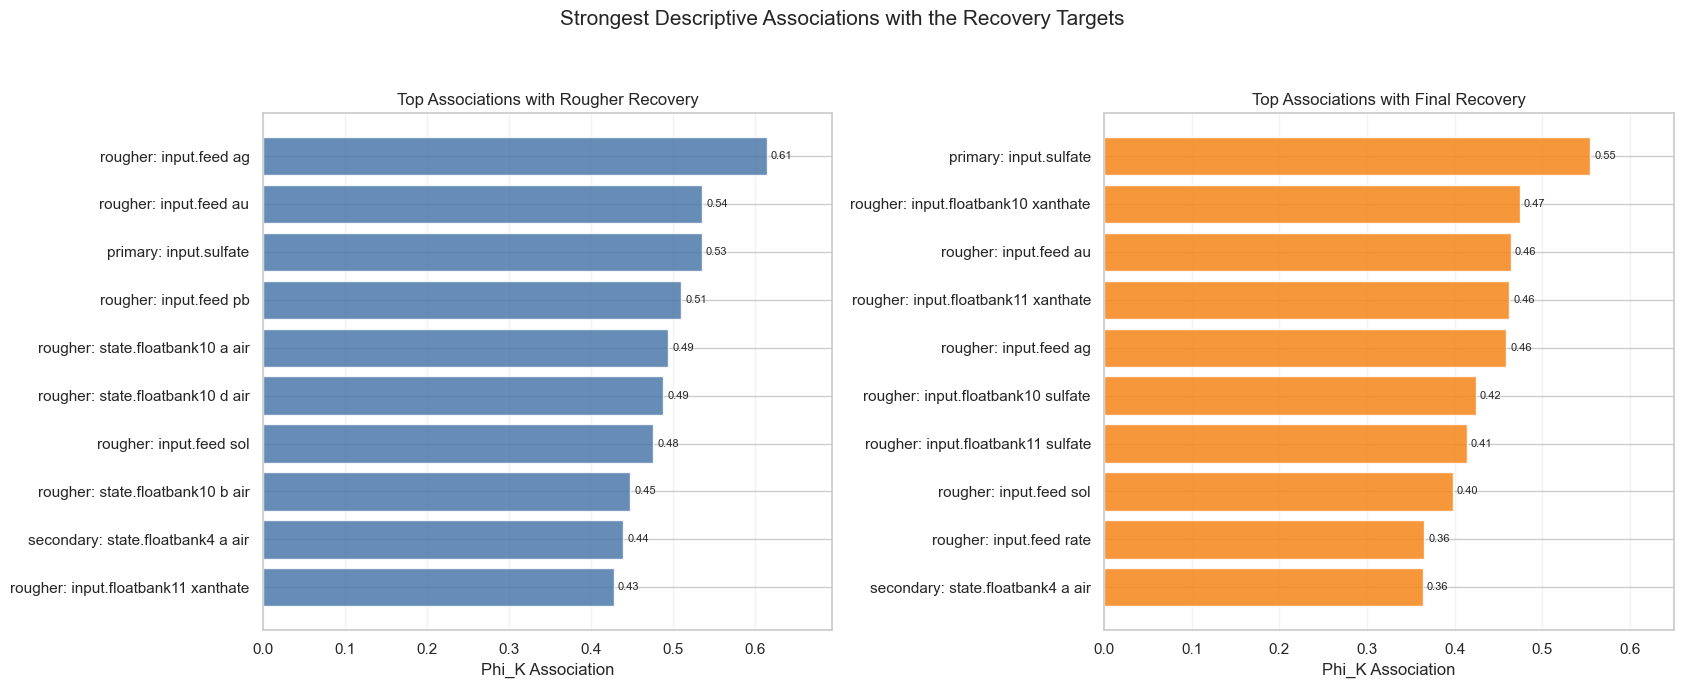

In [275]:
def compact_feature_label(feature):
    return (
        feature
        .replace("rougher.", "rougher: ")
        .replace("primary_cleaner.", "primary: ")
        .replace("secondary_cleaner.", "secondary: ")
        .replace("_", " ")
    )


fig, axes = plt.subplots(1, 2, figsize=(17, 7))

for axis, association_data, title, color in [
    (
        axes[0],
        strong_phik_targets_rougher_filtered,
        "Top Associations with Rougher Recovery",
        "#4C78A8",
    ),
    (
        axes[1],
        strong_phik_targets_final_filtered,
        "Top Associations with Final Recovery",
        "#F58518",
    ),
]:
    plot_data = association_data.head(10).sort_values("phik")
    labels = [compact_feature_label(feature) for feature in plot_data["feature"]]
    bars = axis.barh(labels, plot_data["phik"], color=color, alpha=0.85)
    axis.bar_label(bars, fmt="%.2f", padding=3, fontsize=8)
    axis.set_title(title)
    axis.set_xlabel("Phi_K Association")
    axis.set_xlim(0, max(0.65, plot_data["phik"].max() + 0.08))
    axis.grid(axis="x", alpha=0.25)

fig.suptitle("Strongest Descriptive Associations with the Recovery Targets", fontsize=15)
plt.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()

**Associations with Final Recovery**

The associations between the available process parameters and `final.output.recovery` are also moderate.

The strongest associations involve:

- sulphate input during primary purification: **0.55**;
- xanthate input in rougher flotation unit 10: **0.47**;
- gold concentration in the feed: **0.46**;
- xanthate input in rougher flotation unit 11: **0.46**;
- silver concentration in the feed: **0.46**;
- sulphate inputs in rougher flotation units 10 and 11: **0.42** and **0.41**;
- solids concentration in the feed: **0.40**.

As above, these coefficients quantify association rather than causal influence or predictive importance.

Several rougher-stage feed characteristics - particularly the concentrations of silver, gold, and solids - are among the variables most strongly associated with both target features.

These results support retaining the complete set of parameters available at prediction time rather than selecting features solely from pairwise associations. Tree-based models can evaluate nonlinear relationships and interactions that are not captured by individual Phi_K coefficients.

### Metal Concentration Changes Across Processing Stages

Before training the models, we check the data for consistency with the expected physical process. We also examine changes in metal concentrations across the ore-processing stages to assess the effectiveness of the process.

The concentrations of gold, silver, and lead will be compared across the following stages:

feed -> rougher concentrate -> primary purification -> final concentrate

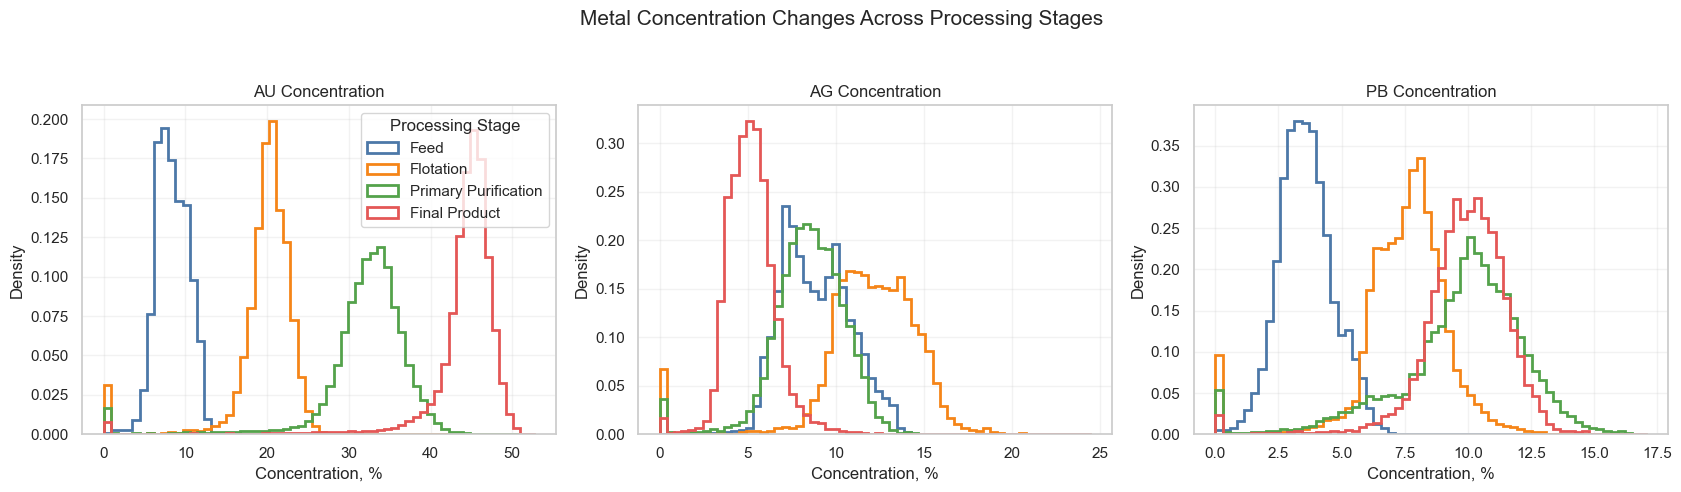

In [276]:
metals = ["au", "ag", "pb"]
stage_columns = {
    "Feed": "rougher.input.feed_{}",
    "Flotation": "rougher.output.concentrate_{}",
    "Primary Purification": "primary_cleaner.output.concentrate_{}",
    "Final Product": "final.output.concentrate_{}",
}

stage_colors = {
    "Feed": "#4C78A8",
    "Flotation": "#F58518",
    "Primary Purification": "#54A24B",
    "Final Product": "#E45756",
}

fig, axes = plt.subplots(1, 3, figsize=(17, 5), squeeze=False)

for axis, metal in zip(axes.ravel(), metals):
    stage_series = {
        stage_name: train_filled[column_pattern.format(metal)].dropna()
        for stage_name, column_pattern in stage_columns.items()
    }
    pooled = pd.concat(stage_series.values(), ignore_index=True)
    common_bins = np.linspace(pooled.min(), pooled.max(), 61)

    for stage_name, series in stage_series.items():
        axis.hist(
            series,
            bins=common_bins,
            density=True,
            histtype="step",
            linewidth=2,
            color=stage_colors[stage_name],
            label=stage_name,
        )

    axis.set_title(f"{metal.upper()} Concentration")
    axis.set_xlabel("Concentration, %")
    axis.set_ylabel("Density")
    axis.grid(alpha=0.25)

axes[0, 0].legend(title="Processing Stage")
fig.suptitle("Metal Concentration Changes Across Processing Stages", fontsize=15)
plt.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()

**Concentration Distributions Across Processing Stages**

**Gold (Au)**

- **Feed:** The distribution peaks near 8 and is moderately asymmetric, which indicates variation in ore grade.
- **Flotation -> primary purification -> final product:** Gold concentration increases consistently at every stage.
- In the final product, most values are concentrated between **40 and 50**.

**Finding:** Gold, the primary metal, becomes progressively more concentrated throughout the process.

---

**Silver (Ag)**

- The feed distribution is bimodal, which may reflect different operating periods or ore compositions. The supplied data do not establish the cause.
- Silver concentration increases after flotation and then decreases during the subsequent purification stages.

**Finding:** Silver follows a less uniform pattern than gold and does not accumulate consistently through every stage.

---

**Lead (Pb)**

- Lead concentration increases after flotation and primary purification.
- The final distribution remains centered near 10-11 but is less stable than the gold distribution.

**Finding:** Lead becomes more concentrated overall, although less consistently than gold.

---

**Overall Findings**

- **Gold** becomes progressively and consistently more concentrated at every processing stage.
- **Silver and lead** exhibit less uniform behavior.
- All target-dependent distributions in this analysis use training observations only.

### Feed Particle Size Distributions in the Training and Test Sets

We compare the feed particle size distributions in the training and test sets to confirm that there are no material differences and that the subsets are representative of the complete dataset.

We examine two features:

- `rougher.input.feed_size` for flotation;
- `primary_cleaner.input.feed_size` for purification.

We compare their distributions in `train` and `test`using two complementary views:

- central-range histograms with identical bins for both subsets;
- full-range empirical cumulative distribution functions (ECDFs), which show the tails without depending on a KDE bandwidth.

The histogram panels display the pooled **0.5th-99.5th** percentile range for readability. This is a visualization-only restriction and does not remove observations.

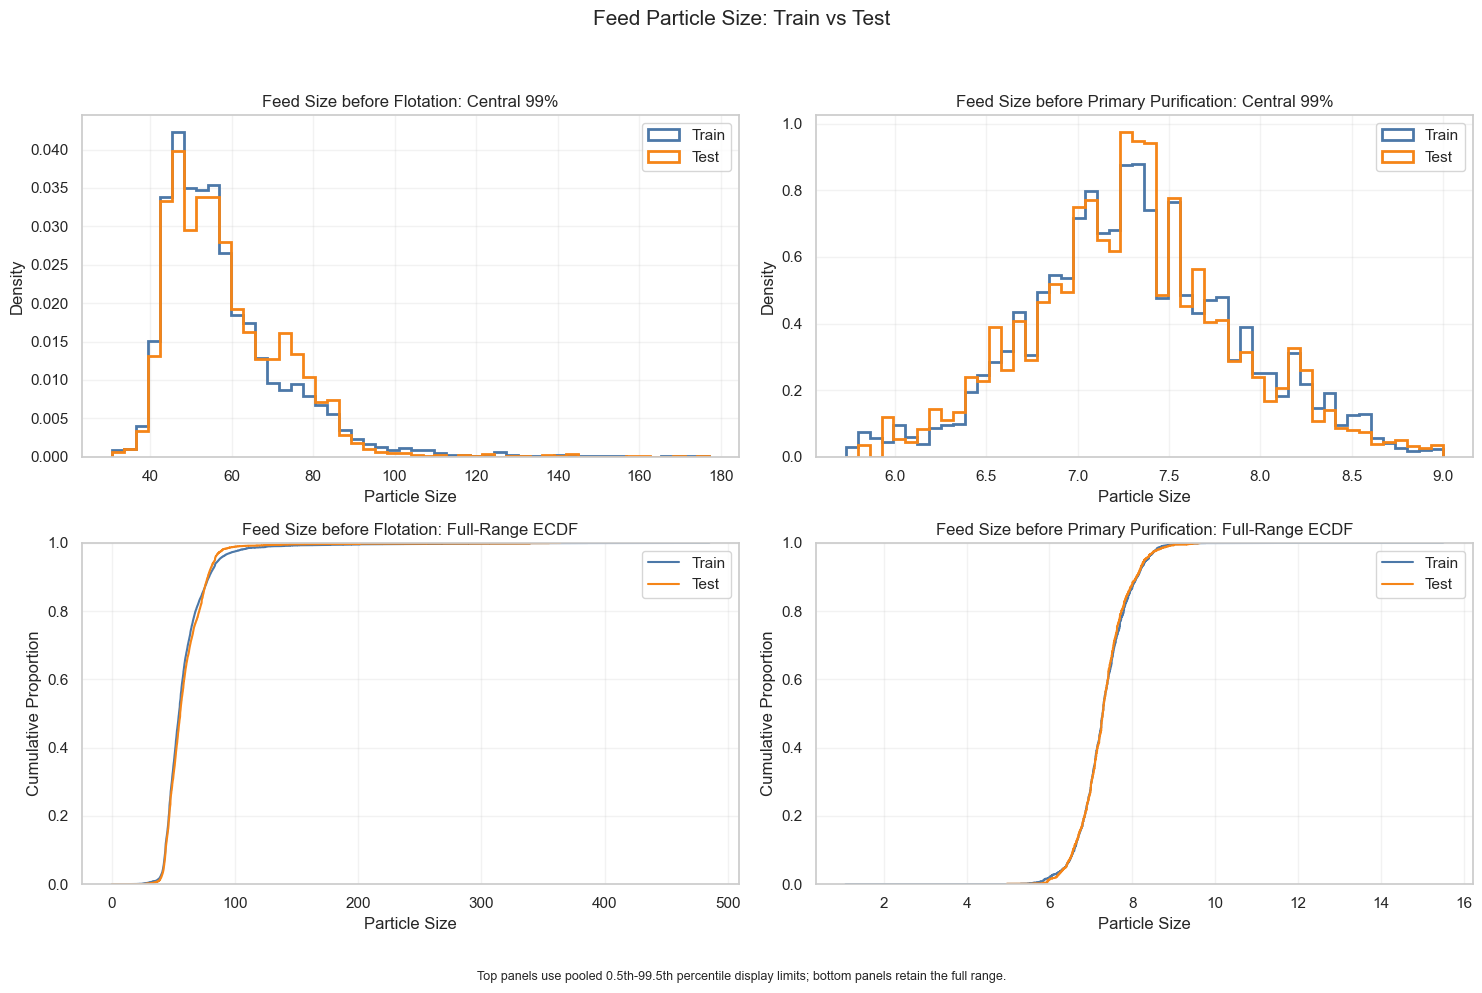

In [277]:
# Compare feed-size features across the chronological training and test periods
features_to_compare = {
    "rougher.input.feed_size": "Feed Size before Flotation",
    "primary_cleaner.input.feed_size": "Feed Size before Primary Purification",
}

fig, axes = plt.subplots(2, 2, figsize=(15, 10), squeeze=False)

for column_index, (feature, title) in enumerate(features_to_compare.items()):
    train_values = train_filled[feature].dropna()
    test_values = test_filled[feature].dropna()
    pooled = pd.concat([train_values, test_values], ignore_index=True)
    lower, upper = pooled.quantile([0.005, 0.995])
    common_bins = np.linspace(lower, upper, 51)

    density_axis = axes[0, column_index]
    density_axis.hist(
        train_values[train_values.between(lower, upper)],
        bins=common_bins,
        density=True,
        histtype="step",
        linewidth=2,
        color="#4C78A8",
        label="Train",
    )
    density_axis.hist(
        test_values[test_values.between(lower, upper)],
        bins=common_bins,
        density=True,
        histtype="step",
        linewidth=2,
        color="#F58518",
        label="Test",
    )
    density_axis.set_title(f"{title}: Central 99%")
    density_axis.set_xlabel("Particle Size")
    density_axis.set_ylabel("Density")
    density_axis.legend()
    density_axis.grid(alpha=0.25)

    ecdf_axis = axes[1, column_index]
    sns.ecdfplot(x=train_values, ax=ecdf_axis, color="#4C78A8", label="Train")
    sns.ecdfplot(x=test_values, ax=ecdf_axis, color="#F58518", label="Test")
    ecdf_axis.set_title(f"{title}: Full-Range ECDF")
    ecdf_axis.set_xlabel("Particle Size")
    ecdf_axis.set_ylabel("Cumulative Proportion")
    ecdf_axis.legend()
    ecdf_axis.grid(alpha=0.25)

fig.suptitle("Feed Particle Size: Train vs Test", fontsize=15)
fig.text(
    0.5,
    0.01,
    "Top panels use pooled 0.5th-99.5th percentile display limits; bottom panels retain the full range.",
    ha="center",
    fontsize=9,
)
plt.tight_layout(rect=(0, 0.04, 1, 0.95))
plt.show()

**Feed Particle Size Comparison**

**Plot 1: `rougher.input.feed_size`**

**Observations:**

- Both chronological periods peak near 60 μm and have similarly shaped main distributions.
- The test period contains slightly more observations near 80 μm.
- Both periods include sparse long tails, which remain visible in the ECDF panel.

**Finding:** No strong univariate shift is visible in the main distribution, although the plots cannot rule out multivariate or temporal distribution shift.

---

**Plot 2: `primary_cleaner.input.feed_size`**

**Observations:**

- Both distributions are narrow and centered near 7 μm.
- Their univariate shapes overlap closely in the central-range histogram and in the full-range ECDF.

**Finding:** The feature is stable across the two periods in this univariate comparison. Chronological validation is still required because similarity in two individual features does not guarantee that the complete feature distribution is unchanged.

### Total Metal Concentration Across Processing Stages

We examine the total concentration of three metals across the principal processing stages:

- gold (Au);
- silver (Ag);
- lead (Pb).

**Stages:**

- `rougher.input` - feed;
- `rougher.output.concentrate` - rougher concentrate;
- `primary_cleaner.output.concentrate` - concentrate after primary purification;
- `final.output.concentrate` - final product.

In [278]:
# Processing stages and column prefixes
stages = {
    "Feed": "rougher.input.feed_",
    "Flotation": "rougher.output.concentrate_",
    "Primary Purification": "primary_cleaner.output.concentrate_",
    "Final Product": "final.output.concentrate_",
}

In [279]:
# Metals
metals = ['au', 'ag', 'pb']

In [280]:
# Dictionary for total metal concentrations in the training period
total_concentrations = {}

In [281]:
# Calculate total Au + Ag + Pb concentration at each stage
for stage_name, prefix in stages.items():
    columns = [prefix + metal for metal in metals]
    total_concentrations[stage_name] = train_filled[columns].sum(axis=1)

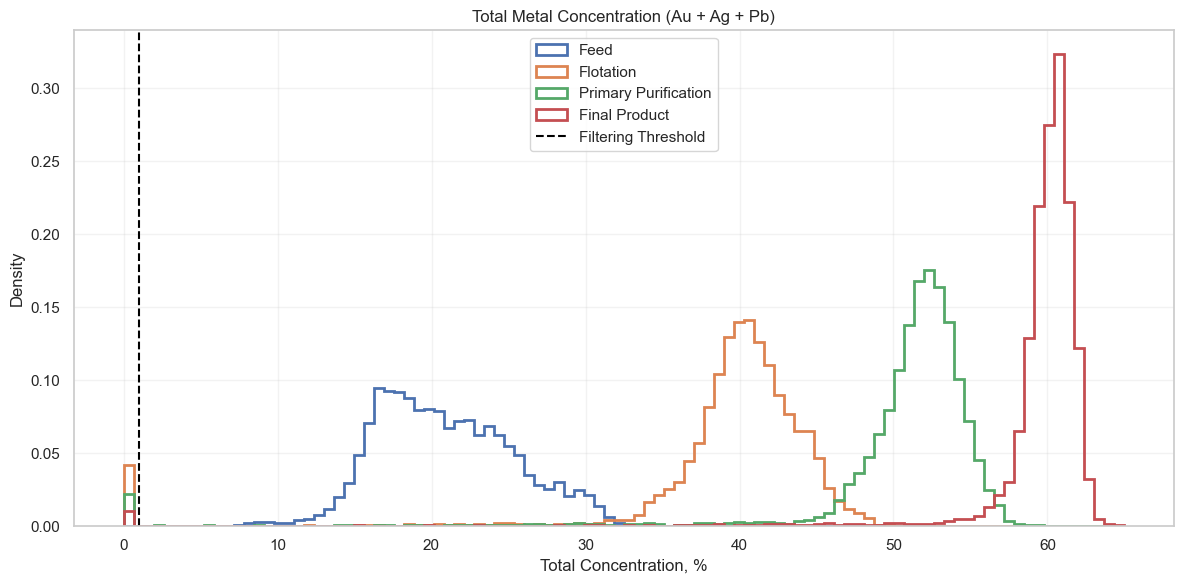

In [282]:
# Visualize all stages using one shared set of bin edges
all_total_values = np.concatenate([
    series.dropna().to_numpy()
    for series in total_concentrations.values()
])
total_bins = np.linspace(all_total_values.min(), all_total_values.max(), 101)

fig, ax = plt.subplots(figsize=(12, 6))
for name, series in total_concentrations.items():
    ax.hist(
        series,
        bins=total_bins,
        density=True,
        histtype="step",
        linewidth=2,
        label=name,
    )

ax.axvline(1, color="black", linestyle="--", linewidth=1.5, label="Filtering Threshold")
ax.set_title("Total Metal Concentration (Au + Ag + Pb)")
ax.set_xlabel("Total Concentration, %")
ax.set_ylabel("Density")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


**Total Metal Concentration Analysis (Au + Ag + Pb)**

The plot shows the following:

1. **The main distribution shifts to the right at every stage:**
   - the feed has the lowest total concentration;
   - flotation increases the concentration substantially;
   - primary purification and the final stage shift it further toward higher values.
2. **The processing stages therefore increase the total concentration of valuable metals**, which is the expected result of removing waste material from the ore.
3. **All four distributions contain left tails.** The output stages also show a distinct group of recorded concentrations close to zero.
4. **The near-zero values are not missing (`NaN`).** Without process logs, they can only be treated as possible shutdown, unstable-batch, sensor, or recording anomalies; a definite cause cannot be assigned from the dataset alone.

---

**Findings:**

- Total metal concentration increases from the feed through flotation and purification to the final product.
- The isolated near-zero group should be treated before model training so that abnormal output periods do not distort model selection.
- The filter will be derived from and applied to the training set only. Test rows will not be selected using output concentrations because those quantities are unavailable when predictions are made.

### Data Analysis: Section Summary

**Outlier analysis**

- IQR-based potential **outliers** occur in many training features, particularly in process-state variables.
- They were retained because their process meaning is unknown and automatic removal could discard legitimate operating regimes.
- **Negative liquid-level** values occur systematically and are likely related to the measurement scale rather than isolated errors.
- **Negative calculated ratios** were not used as model features.

**Feature association analysis**

- The strongest association with `rougher.output.recovery` is **feed silver** concentration (**0.61**), followed by **feed gold** concentration (**0.54**), **primary-cleaner sulphate** input (**0.53**), **feed lead** concentration (**0.51**), **rougher air** volumes (approximately **0.49**), and **feed solids** concentration (**0.48**).
  
- The strongest association with `final.output.recovery` is **primary-cleaner sulphate** input (**0.55**), followed by **rougher xanthate** inputs (**0.47** and **0.46**), **feed gold** and **silver** concentrations (approximately **0.46**), **rougher sulphate** inputs (**0.42** and **0.41**), and **feed solids** concentration (**0.40**).
- These relationships are associations rather than evidence of causality or model feature importance.

**Metal concentration changes**

- **Gold** becomes progressively more concentrated at every processing stage.
- **Silver** and lead exhibit less uniform behavior.
- Total **Au + Ag + Pb** concentration increases from the feed through flotation and purification to the final product.

**Feed particle size distributions**

- `rougher.input.feed_size` peaks near **60 μm** in both chronological periods.
- `primary_cleaner.input.feed_size` is centered near **7 μm** in both periods.
- No strong univariate shift is visible in these two features, although several other input and state variables show changes in modal structure.

**Anomaly treatment**

- Target-dependent analysis was restricted to the training period.
- The distinct near-zero concentration group will be removed from training only; the complete later test period will remain untouched.

## Modeling

### Preparing the Data and Removing Anomalies

Before modeling, we remove the **near-zero anomalies** identified in the previous section from the training set only.

Rows with **zero** or **near-zero total metal concentrations** form isolated peaks and may represent shutdowns or abnormal operating periods. We remain the test set unchanged because output concentrations are unavailable at prediction time and therefore cannot be used to decide which test observations to retain.

First, we create columns containing the total metal concentration at each processing stage for the training data.

In [283]:
# Create total-concentration columns in the training set only
train_filled["sum_feed"] = train_filled[
    ["rougher.input.feed_au", "rougher.input.feed_ag", "rougher.input.feed_pb"]
].sum(axis=1)

In [284]:
train_filled["sum_rougher"] = train_filled[
    [
        "rougher.output.concentrate_au",
        "rougher.output.concentrate_ag",
        "rougher.output.concentrate_pb",
    ]
].sum(axis=1)

In [285]:
train_filled["sum_primary"] = train_filled[
    [
        "primary_cleaner.output.concentrate_au",
        "primary_cleaner.output.concentrate_ag",
        "primary_cleaner.output.concentrate_pb",
    ]
].sum(axis=1)

In [286]:
train_filled["sum_final"] = train_filled[
    ["final.output.concentrate_au", "final.output.concentrate_ag", "final.output.concentrate_pb"]
].sum(axis=1)

In [287]:
# Preserve an unfiltered copy for reporting
train_before_filtering = train_filled.copy()

We use a **threshold of 1** to separate the distinct **near-zero concentration group** identified in the training distributions.

We apply the threshold to the concentration totals at all four analyzed stages: feed, rougher concentrate, primary-cleaner concentrate, and final concentrate. These diagnostic columns will not be included in the model features.

In [288]:
# Define the eps threshold
eps = 1

We filter the DataFrame to retain only rows whose total metal concentration exceeds the threshold at every stage.

In [289]:
# Filter anomalous rows from training only
concentration_columns = ["sum_feed", "sum_rougher", "sum_primary", "sum_final"]
train_anomaly_mask = (train_filled[concentration_columns] > eps).all(axis=1)
train_filled_clean = train_filled.loc[train_anomaly_mask].copy()

In [290]:
display(f"Training shape before filtering: {train_filled.shape}")
display(f"Training shape after filtering:  {train_filled_clean.shape}")
display(f"Removed training rows: {(~train_anomaly_mask).sum()}")
display(f"Retained training share: {train_anomaly_mask.mean():.2%}")
display(f"Test rows retained: {len(test_filled)} of {len(test)}")

'Training shape before filtering: (14579, 91)'

'Training shape after filtering:  (13883, 91)'

'Removed training rows: 696'

'Retained training share: 95.23%'

'Test rows retained: 4860 of 4860'

**Result**

The anomalous near-zero group was removed from the training set only. A total of **696 training observations** were excluded, while the complete chronological test set of **4,860 observations** remains **untouched** for final evaluation.

More than 95% of the original training observations remain, which is sufficient for model development.

Let's inspect The filtered distributions visually.

In [291]:
# Recalculate filtered training distributions without reusing stale series
total_concentrations_clean = {}
for stage_name, prefix in stages.items():
    columns = [prefix + metal for metal in metals]
    total_concentrations_clean[stage_name] = train_filled_clean[columns].sum(axis=1)

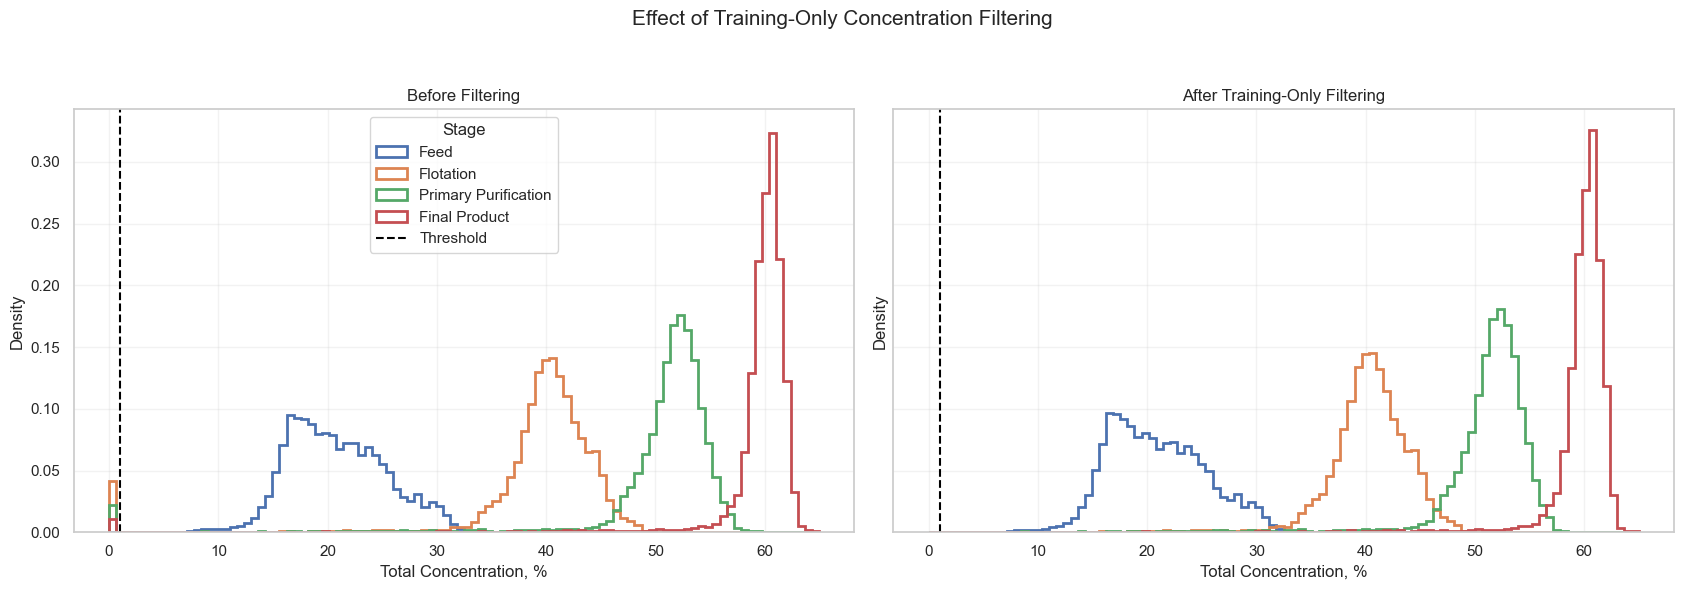

In [292]:
# Compare the same distributions before and after filtering
fig, axes = plt.subplots(1, 2, figsize=(17, 6), sharex=True, sharey=True)

for axis, title, distributions in [
    (axes[0], "Before Filtering", total_concentrations),
    (axes[1], "After Training-Only Filtering", total_concentrations_clean),
]:
    for name, series in distributions.items():
        axis.hist(
            series,
            bins=total_bins,
            density=True,
            histtype="step",
            linewidth=2,
            label=name,
        )
    axis.axvline(eps, color="black", linestyle="--", linewidth=1.5, label="Threshold")
    axis.set_title(title)
    axis.set_xlabel("Total Concentration, %")
    axis.set_ylabel("Density")
    axis.grid(alpha=0.25)

axes[0].legend(title="Stage")
fig.suptitle("Effect of Training-Only Concentration Filtering", fontsize=15)
plt.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()

**Result**

The isolated zero and near-zero concentration peaks were removed successfully from the training data. No test output values were used for filtering, and the test sample was not changed.

### Feature Preparation

We take the authoritative **feature list** directly from the original test dataset. This ensures that the model uses only parameters that are genuinely available when predictions are made and prevents newly created diagnostic columns or output variables from entering the feature matrices.

We retrieve the **two target values** for the test observations from `full` by matching the **timestamps**. We will use them only after prediction to evaluate the final models.

In [293]:
# Create chronologically indexed modeling datasets
train_model = train_filled_clean.set_index("date").sort_index()
test_model = test_filled.set_index("date").sort_index()

display(f"Filtered training shape: {train_model.shape}")
display(f"Untouched test shape:    {test_model.shape}")
display(f"Training period: {train_model.index.min()} to {train_model.index.max()}")
display(f"Test period:     {test_model.index.min()} to {test_model.index.max()}")

'Filtered training shape: (13883, 90)'

'Untouched test shape:    (4860, 52)'

'Training period: 2016-01-15 00:00:00 to 2017-12-09 13:59:59'

'Test period:     2017-12-09 14:59:59 to 2018-08-18 10:59:59'

**Result**

The target features for the filtered training observations will now be extracted.

We retrieve the corresponding test targets from the complete dataset by matching the timestamps. We will keep them separate from feature preparation, model fitting, and hyperparameter selection and use only for final evaluation.

In [294]:
target_columns = ["rougher.output.recovery", "final.output.recovery"]

target_train = train_model[target_columns].copy()

full_targets = (
    full_new.set_index("date")
    .sort_index()[target_columns]
)
target_test = full_targets.loc[test_model.index].copy()

assert target_train.notna().all().all()
assert target_test.notna().all().all()

Now, we select the features available for model training.  We restrictt the feature list to the numeric columns that are present in the original test file.

In [295]:
# Use the original test schema as the authoritative list of available features
feature_columns = [column for column in test.columns if column != "date"]

features_train = train_model[feature_columns].copy()
features_test = test_model[feature_columns].copy()

forbidden_features = {
    "set",
    "sum_feed",
    "sum_rougher",
    "sum_primary",
    "sum_final",
    *target_columns,
}

assert not forbidden_features.intersection(features_train.columns)
assert not forbidden_features.intersection(features_test.columns)

We check the columns and row alignment for consistency in the training and test feature sets.

In [296]:
assert features_train.columns.equals(features_test.columns)
assert list(features_train.columns) == feature_columns
assert features_train.index.equals(target_train.index)
assert features_test.index.equals(target_test.index)

display(f"Available model features: {features_train.shape[1]}")
display(f"Training observations: {features_train.shape[0]}")
display(f"Test observations: {features_test.shape[0]}")

'Available model features: 52'

'Training observations: 13883'

'Test observations: 4860'

**Result**

The feature columns in the two subsets match.

Both matrices contain the same **52 numeric input** and **state parameters** from the original test schema. Calculated concentration totals, output parameters, target variables, and dataset labels are not present.

The project has two target features corresponding to different purification stages. Because the stages differ in both timing and available process information, each target should be modeled separately.

The **rougher model** will use the **22 rougher-stage input** and **state features** available before rougher recovery is known.\
The **final model** will use **all 52 parameters** available before final recovery is known.\
Separate feature and target datasets will therefore be prepared for the two stages.

In [297]:
# Rougher-recovery data
rougher_feature_columns = [
    column for column in feature_columns
    if column.startswith("rougher.")
]

features_train_r = features_train[rougher_feature_columns].copy()
features_test_r = features_test[rougher_feature_columns].copy()
target_train_r = target_train["rougher.output.recovery"]
target_test_r = target_test["rougher.output.recovery"]

# Final-recovery data
features_train_f = features_train.copy()
features_test_f = features_test.copy()
target_train_f = target_train["final.output.recovery"]
target_test_f = target_test["final.output.recovery"]

In [298]:
# Inspect and validate the final feature sets
display(f"Rougher feature count: {features_train_r.shape[1]}")
display(f"Final feature count:   {features_train_f.shape[1]}")
display(f"Forbidden features present: {forbidden_features.intersection(features_train_f.columns)}")

assert features_train_r.select_dtypes(exclude="number").empty
assert features_train_f.select_dtypes(exclude="number").empty

'Rougher feature count: 22'

'Final feature count:   52'

'Forbidden features present: set()'

**Result**

The feature and target datasets were prepared successfully. The test sample occurs chronologically after the training sample and remains completely independent of model fitting and hyperparameter selection.

### Implementing the sMAPE Function

The project requires the use of **sMAPE (Symmetric Mean Absolute Percentage Error)**.

This metric is similar to MAE but expresses the error in relative terms as a **percentage**. It is described as symmetric because it accounts for the scale of the target and prediction equally.

sMAPE measures the average percentage difference between predicted and actual values. **Lower values indicate more accurate predictions**.

**sMAPE Formula**

In [299]:
#sMAPE formula
# Display the formula image
display(Image(url='https://pictures.s3.yandex.net/resources/smape_1576239058.jpg'))

*Notation:*

In [300]:
display(Image(url='https://pictures.s3.yandex.net/resources/y1_1576238832.jpg'))
display('Target value for observation i in the evaluation dataset')

'Target value for observation i in the evaluation dataset'

In [301]:
display(Image(url='https://pictures.s3.yandex.net/resources/yi_1_1576238835.jpg'))
display('Predicted value for observation i, for example in the test set')

'Predicted value for observation i, for example in the test set'

In [302]:
display(Image(url='https://pictures.s3.yandex.net/resources/N_1_1576238819.jpg'))
display('Number of observations in the dataset')

'Number of observations in the dataset'

In [303]:
display(Image(url='https://pictures.s3.yandex.net/resources/I_1576238817.jpg'))
display('Summation over all observations, where i ranges from 1 to N')

'Summation over all observations, where i ranges from 1 to N'

We implement the sMAPE formula as a function:

In [304]:
#Symmetric Mean Absolute Percentage Error (sMAPE)
def smape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    denominator = np.where(denominator == 0, 1, denominator)  # avoid division by zero
    diff = np.abs(y_true - y_pred) / denominator
    return np.mean(diff) * 100

**Final sMAPE Formula**

In [305]:
#Final sMAPE formula
# Display the formula image
display(Image(url='https://pictures.s3.yandex.net/resources/_smape_1576239054.jpg'))

We implement the final sMAPE formula as a function:

In [306]:
def final_smape(y_true_rougher, y_pred_rougher,
                y_true_final, y_pred_final):
    smape_rougher = smape(y_true_rougher, y_pred_rougher)
    smape_final = smape(y_true_final, y_pred_final)
    return (0.25*smape_rougher +  0.75*smape_final)

### Model Preparation

We use tree-based regression models for this task because they can capture nonlinear relationships and interactions between process parameters.

We evaluate two regression algorithms:

- `RandomForestRegressor`;
- `CatBoostRegressor`.

#### Feature Matrix Validation

We validate the feature matrices before model training.

In [307]:
# Confirm that all features are numeric and finite
assert features_train_r.select_dtypes(exclude="number").empty
assert features_train_f.select_dtypes(exclude="number").empty
assert np.isfinite(features_train_r.to_numpy()).all()
assert np.isfinite(features_train_f.to_numpy()).all()

In [308]:
# Confirm chronological order before time-series cross-validation
assert features_train_r.index.is_monotonic_increasing
assert features_train_f.index.is_monotonic_increasing
assert features_train_r.index.max() < features_test_r.index.min()
assert features_train_f.index.max() < features_test_f.index.min()

In [309]:
# Confirm identical train/test schemas for each target
assert features_train_r.columns.equals(features_test_r.columns)
assert features_train_f.columns.equals(features_test_f.columns)

In [310]:
display("Rougher matrices:", features_train_r.shape, features_test_r.shape)
display("Final matrices:", features_train_f.shape, features_test_f.shape)

'Rougher matrices:'

(13883, 22)

(4860, 22)

'Final matrices:'

(13883, 52)

(4860, 52)

**Result**

The feature matrices contain only numeric, finite values, have identical train/test schemas, and are ordered chronologically. No output-derived variables unavailable at prediction time were identified.

#### Model Training

We use cross-validation during training to obtain a more reliable estimate of model quality and select the best hyperparameters.

Because the observations form a chronological process series, the folds must preserve time order. Every validation period will therefore occur strictly after its corresponding training period, preventing future neighboring observations from entering model training.

`TimeSeriesSplit` will create five expanding-window folds. For each fold, the model is fitted on earlier observations and evaluated on the following period, after which the score is averaged across all folds.

The final test period remains completely excluded from hyperparameter selection.

In [311]:
# sMAPE is a loss: lower values are better
smape_scorer = make_scorer(smape, greater_is_better=False)

In [312]:
time_series_cv = TimeSeriesSplit(n_splits=5)

Next, we evaluated Two regression algorithms:

- `RandomForestRegressor`;
- `CatBoostRegressor`.

`RandomForestRegressor` and `CatBoostRegressor` are tree-based models and do not require feature standardization. Feature scaling will therefore be omitted. This also eliminates the need to fit a separate scaler within each chronological cross-validation fold.

We define hyperparameter grids for both algorithms.

In [313]:
# Compact, reproducible grids for the two tree-based model families
param_grid_rf = {
    "n_estimators": [100, 200],
    "max_depth": [4, 8],
}

param_grid_cb = {
    "iterations": [100, 200],
    "depth": [4, 6],
    "learning_rate": [0.03, 0.1],
    "l2_leaf_reg": [3],
}

Create a **function** to evaluate the hyperparameter combinations for `Random Forest` and `CatBoost` using the same chronological folds and select the configuration with the **lowest mean sMAPE**.

We use a compact **grid of moderate-complexity configurations**. This provides a direct comparison of the two model families while limiting unnecessary runtime and avoiding excessively deep candidates. We retaine **Single-process execution** is retained for reproducibility in restricted notebook environments.

In [314]:
%%time
def find_best_model_time_series(features, target, param_grid_rf, param_grid_cb):
    results = []

    # Random Forest
    for n_estimators in param_grid_rf["n_estimators"]:
        for max_depth in param_grid_rf["max_depth"]:
            model = RandomForestRegressor(
                random_state=RANDOM_STATE,
                n_estimators=n_estimators,
                max_depth=max_depth,
                n_jobs=1,
            )
            fold_scores = -cross_val_score(
                model,
                features,
                target,
                cv=time_series_cv,
                scoring=smape_scorer,
                n_jobs=1,
            )
            results.append({
                "model": "RandomForest",
                "params": {
                    "n_estimators": n_estimators,
                    "max_depth": max_depth,
                },
                "score": fold_scores.mean(),
                "score_std": fold_scores.std(),
            })

    # CatBoost
    for iterations in param_grid_cb["iterations"]:
        for depth in param_grid_cb["depth"]:
            for learning_rate in param_grid_cb["learning_rate"]:
                for l2_leaf_reg in param_grid_cb["l2_leaf_reg"]:
                    model = CatBoostRegressor(
                        random_state=RANDOM_STATE,
                        verbose=0,
                        allow_writing_files=False,
                        thread_count=1,
                        iterations=iterations,
                        depth=depth,
                        learning_rate=learning_rate,
                        l2_leaf_reg=l2_leaf_reg,
                    )
                    fold_scores = -cross_val_score(
                        model,
                        features,
                        target,
                        cv=time_series_cv,
                        scoring=smape_scorer,
                        n_jobs=1,
                    )
                    results.append({
                        "model": "CatBoost",
                        "params": {
                            "iterations": iterations,
                            "depth": depth,
                            "learning_rate": learning_rate,
                            "l2_leaf_reg": l2_leaf_reg,
                        },
                        "score": fold_scores.mean(),
                        "score_std": fold_scores.std(),
                    })

    results_df = pd.DataFrame(results).sort_values("score").reset_index(drop=True)
    best_row = results_df.iloc[0]

    return best_row["model"], best_row["score"], best_row["params"], results_df

CPU times: total: 0 ns
Wall time: 0 ns


First, we identify the best model for predicting **rougher concentrate recovery (`rougher.output.recovery`)** using the function.

In [315]:
%%time

# Chronological search for the rougher target
best_model_name_r, best_score_r, best_params_r, results_r = find_best_model_time_series(
    features_train_r,
    target_train_r,
    param_grid_rf,
    param_grid_cb,
)

CPU times: total: 5min 1s
Wall time: 5min 28s


Next, we instantiate the **best rougher-stage model** using the selected hyperparameters.

In [316]:
if best_model_name_r == "RandomForest":
    best_model_r = RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_jobs=1,
        **best_params_r,
    )
else:
    best_model_r = CatBoostRegressor(
        random_state=RANDOM_STATE,
        verbose=0,
        allow_writing_files=False,
        **best_params_r,
    )

We inspecte the **leading configurations** and the selected model.

In [317]:
display(results_r[results_r['model'] == "RandomForest"].sort_values(by="score", ascending=True).head(3))

display(results_r[results_r['model'] == "CatBoost"].sort_values(by="score", ascending=True).head(3))

,model,params,score,score_std
7,RandomForest,"{'n_estimators': 100, 'max_depth': 4}",7.317748,1.614571
8,RandomForest,"{'n_estimators': 200, 'max_depth': 4}",7.341853,1.625728
10,RandomForest,"{'n_estimators': 100, 'max_depth': 8}",7.868885,2.181854


,model,params,score,score_std
0,CatBoost,"{'iterations': 100, 'depth': 4, 'learning_rate...",6.655005,0.760303
1,CatBoost,"{'iterations': 200, 'depth': 4, 'learning_rate...",6.712201,0.897859
2,CatBoost,"{'iterations': 100, 'depth': 4, 'learning_rate...",6.805259,1.118439


In [318]:
display(f"Best model for Rougher: {best_model_name_r}, "
      f"sMAPE CV = {best_score_r:.3f}, parameters = {best_params_r}")

"Best model for Rougher: CatBoost, sMAPE CV = 6.655, parameters = {'iterations': 100, 'depth': 4, 'learning_rate': 0.03, 'l2_leaf_reg': 3}"

Then we identify the best model for predicting **final concentrate recovery (`final.output.recovery`)** using the function.

In [319]:
%%time

# Chronological search for the final target
best_model_name_f, best_score_f, best_params_f, results_f = find_best_model_time_series(
    features_train_f,
    target_train_f,
    param_grid_rf,
    param_grid_cb,
)

CPU times: total: 11min 42s
Wall time: 13min 7s


We instantiate the best final-stage model using the selected hyperparameters.

In [320]:
if best_model_name_f == "RandomForest":
    best_model_f = RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_jobs=1,
        **best_params_f,
    )
else:
    best_model_f = CatBoostRegressor(
        random_state=RANDOM_STATE,
        verbose=0,
        allow_writing_files=False,
        **best_params_f,
    )

Now inspecte the leading configurations and the selected model.

In [321]:
display(results_f[results_f['model'] == "RandomForest"].sort_values(by="score", ascending=True).head(3))

display(results_f[results_f['model'] == "CatBoost"].sort_values(by="score", ascending=True).head(3))

,model,params,score,score_std
7,RandomForest,"{'n_estimators': 100, 'max_depth': 4}",9.205738,1.113972
8,RandomForest,"{'n_estimators': 200, 'max_depth': 4}",9.315937,1.069152
10,RandomForest,"{'n_estimators': 100, 'max_depth': 8}",9.585056,1.149645


,model,params,score,score_std
0,CatBoost,"{'iterations': 100, 'depth': 4, 'learning_rate...",8.922874,1.071159
1,CatBoost,"{'iterations': 100, 'depth': 6, 'learning_rate...",9.008909,1.199127
2,CatBoost,"{'iterations': 200, 'depth': 6, 'learning_rate...",9.019887,1.437809


In [322]:
display(f"Best model for Final: {best_model_name_f}, "
      f"sMAPE CV = {best_score_f:.3f}, parameters = {best_params_f}")

"Best model for Final: CatBoost, sMAPE CV = 8.923, parameters = {'iterations': 100, 'depth': 4, 'learning_rate': 0.03, 'l2_leaf_reg': 3}"

**Result**

**CatBoost** achieved the best chronological cross-validation result for both target features.

The same moderate-complexity configuration was selected for the two models: 100 iterations, depth 4, learning rate 0.03, and L2 regularization 3.

- Rougher recovery sMAPE: **6.655%** (fold standard deviation: 0.760 percentage points).
- Final recovery sMAPE: **8.923%** (fold standard deviation: 1.071 percentage points).
- Weighted chronological sMAPE: **8.356%**.

These values are higher than the in-sample errors expected after refitting, because every validation score is calculated on a later period that was not used to train the corresponding fold model.

#### Final Model Evaluation

We fitt the selected models on all filtered training observations.

We will first generate predictions for the training set as an in-sample diagnostic. These values describe how closely the final models fit observations they have already seen; generalization will be assessed using chronological cross-validation and the untouched later test period.

In [323]:
# Fit the selected models on all filtered training observations
best_model_r.fit(features_train_r, target_train_r)
best_model_f.fit(features_train_f, target_train_f)

CatBoostRegressor(allow_writing_files=False, depth=4, iterations=100, l2_leaf_reg=3, learning_rate=0.03, loss_function='RMSE', random_state=678, verbose=0)

In [324]:
# In-sample predictions for diagnostic purposes
pred_r_train = best_model_r.predict(features_train_r)
pred_f_train = best_model_f.predict(features_train_f)

In [325]:
# final_smape
train_smape_r = smape(target_train_r, pred_r_train)
train_smape_f = smape(target_train_f, pred_f_train)
train_final_smape = final_smape(
    target_train_r,
    pred_r_train,
    target_train_f,
    pred_f_train,
)

In [326]:
display(f"In-sample rougher sMAPE: {train_smape_r:.3f}%")
display(f"In-sample final-target sMAPE: {train_smape_f:.3f}%")
display(f"In-sample weighted final sMAPE: {train_final_smape:.3f}%")

'In-sample rougher sMAPE: 4.300%'

'In-sample final-target sMAPE: 7.361%'

'In-sample weighted final sMAPE: 6.596%'

The in-sample sMAPE values are:

- rougher recovery: **4.300%**;
- final recovery: **7.361%**;
- weighted final metric: **6.596%**.

As expected, these results are lower than the chronological cross-validation scores because the observations were used for model fitting. They are therefore reported only as diagnostics and should not be treated as estimates of future performance.

#### Predictions on the Untouched Test Period

In [327]:
# Generate predictions for the untouched test feature matrices
pred_r_test = best_model_r.predict(features_test_r)
pred_f_test = best_model_f.predict(features_test_f)

In [328]:
# Evaluate target-specific and weighted test metrics
test_smape_r = smape(target_test_r, pred_r_test)
test_smape_f = smape(target_test_f, pred_f_test)
test_final_smape = final_smape(
    target_test_r,
    pred_r_test,
    target_test_f,
    pred_f_test,
)

In [329]:
display(f"Test rougher sMAPE: {test_smape_r:.3f}%")
display(f"Test final-target sMAPE: {test_smape_f:.3f}%")

'Test rougher sMAPE: 4.166%'

'Test final-target sMAPE: 7.515%'

In [330]:
display(f"Test weighted final sMAPE: {test_final_smape:.3f}%")

'Test weighted final sMAPE: 6.678%'

In [331]:
# Combine target-specific chronological CV scores using the project weights
cv_final_smape = 0.25 * best_score_r + 0.75 * best_score_f
generalization_gap = test_final_smape - cv_final_smape

display(f"Chronological CV weighted sMAPE: {cv_final_smape:.3f}%")
display(f"Test minus CV weighted sMAPE: {generalization_gap:.3f} percentage points")

'Chronological CV weighted sMAPE: 8.356%'

'Test minus CV weighted sMAPE: -1.678 percentage points'

The final models were evaluated on all **4,860 untouched test observations**.

- Rougher recovery sMAPE: **4.166%**.
- Final recovery sMAPE: **7.515%**.
- Weighted final sMAPE: **6.678%**.

The weighted test result is 1.678 percentage points lower than the chronological cross-validation estimate of 8.356%. The expanding-window validation was therefore conservative for this particular later period.

This is a valid out-of-sample comparison because the test observations were not used for preprocessing decisions, filtering, fitting, or hyperparameter selection. Nevertheless, one test period cannot establish performance under every future operating regime.

### Comparison with a Constant Baseline

#### Numerical Comparison with the Baseline

For a more complete assessment, we compare the selected models with a constant `DummyRegressor` baseline that predicts the training-target median for every observation.

We fit a separate baseline for each target and applied unchanged to the same untouched test period. This comparison will show whether the machine-learning models capture useful relationships beyond the central target value.

In [ ]:
# Fit and evaluate a training-median baseline
def evaluate_dummy(features_train, target_train, features_test, target_test):
    dummy = DummyRegressor(strategy="median")
    dummy.fit(features_train, target_train)

    pred_train = dummy.predict(features_train)
    pred_test = dummy.predict(features_test)

    return {
        "model": dummy,
        "pred_train": pred_train,
        "pred_test": pred_test,
        "smape_train": smape(target_train, pred_train),
        "smape_test": smape(target_test, pred_test),
    }

In [ ]:
# Dummy baseline for rougher recovery
dummy_r = evaluate_dummy(
    features_train_r,
    target_train_r,
    features_test_r,
    target_test_r,
)

In [ ]:
# Dummy baseline for final recovery
dummy_f = evaluate_dummy(
    features_train_f,
    target_train_f,
    features_test_f,
    target_test_f,
)

In [ ]:
display("DummyRegressor Results:")
display(
    f"Rougher - train: {dummy_r['smape_train']:.3f}%, "
    f"test: {dummy_r['smape_test']:.3f}%"
)
display(
    f"Final - train: {dummy_f['smape_train']:.3f}%, "
    f"test: {dummy_f['smape_test']:.3f}%"
)

In [ ]:
# Compare the selected models and baselines on the same untouched test rows
rougher_improvement = dummy_r["smape_test"] - test_smape_r
final_target_improvement = dummy_f["smape_test"] - test_smape_f

In [ ]:
display(f"Rougher test improvement: {rougher_improvement:.3f} percentage points")
display(f"Final-target test improvement: {final_target_improvement:.3f} percentage points")

In [ ]:
# Weighted final sMAPE for the training-median baseline
final_smape_dummy_train = final_smape(
    target_train_r,
    dummy_r["pred_train"],
    target_train_f,
    dummy_f["pred_train"],
)

In [ ]:
final_smape_dummy_test = final_smape(
    target_test_r,
    dummy_r["pred_test"],
    target_test_f,
    dummy_f["pred_test"],
)

In [ ]:
display(f"Dummy weighted final sMAPE on train: {final_smape_dummy_train:.3f}%")
display(f"Dummy weighted final sMAPE on test: {final_smape_dummy_test:.3f}%")

In [ ]:
weighted_improvement = final_smape_dummy_test - test_final_smape
relative_error_reduction = weighted_improvement / final_smape_dummy_test

In [ ]:
display(f"Weighted test improvement: {weighted_improvement:.3f} percentage points")
display(f"Relative error reduction: {relative_error_reduction:.1%}")

The two training-median `DummyRegressor` baselines produced a weighted test sMAPE of **8.295%**, compared with **6.678%** for the selected CatBoost models.

---

**Comparison with the Baseline**

- Rougher test sMAPE reduction: **1.669 percentage points**.
- Final-target test sMAPE reduction: **1.600 percentage points**.
- Weighted test sMAPE reduction: **1.618 percentage points**.
- Relative reduction in weighted test sMAPE: **19.5%**.

All comparisons are based on predictions for the same untouched test observations, and the baseline constants were estimated using the training targets only. The CatBoost models therefore capture useful predictive relationships in the process data rather than merely reproducing the training-target medians.

#### Visual Comparison of Model Performance

We examine the performance of the selected CatBoost models visually to complement the numerical evaluation. First, we compare their target-specific and weighted test sMAPE values with those of the median `DummyRegressor`. Because sMAPE is an error metric, lower values indicate better performance.

Then we plot the actual and predicted recovery rates across the chronological test period. We will use a **168-observation** rolling mean to make the temporal patterns easier to interpret. This smoothing is applied only to the visualization; all reported sMAPE values are calculated from the original, unsmoothed predictions.

In [ ]:
metric_labels = ["Rougher", "Final Target", "Weighted"]
selected_scores = [test_smape_r, test_smape_f, test_final_smape]
baseline_scores = [dummy_r["smape_test"], dummy_f["smape_test"], final_smape_dummy_test]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

x = np.arange(len(metric_labels))
width = 0.36
selected_bars = axes[0].bar(
    x - width / 2,
    selected_scores,
    width,
    label="Selected CatBoost Models",
    color="#4C78A8",
)
baseline_bars = axes[0].bar(
    x + width / 2,
    baseline_scores,
    width,
    label="Training-Median Baseline",
    color="#BAB0AC",
)
axes[0].bar_label(selected_bars, fmt="%.3f", padding=3)
axes[0].bar_label(baseline_bars, fmt="%.3f", padding=3)
axes[0].set_xticks(x, metric_labels)
axes[0].set_ylabel("sMAPE, %")
axes[0].set_title("Test Performance by Target")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.25)

context_labels = ["Chronological CV", "Untouched Test", "Median Baseline"]
context_scores = [cv_final_smape, test_final_smape, final_smape_dummy_test]
context_colors = ["#F58518", "#4C78A8", "#BAB0AC"]
context_bars = axes[1].bar(context_labels, context_scores, color=context_colors)
axes[1].bar_label(context_bars, fmt="%.3f", padding=3)
axes[1].set_ylabel("Weighted sMAPE, %")
axes[1].set_title("Weighted Out-of-Sample Metrics")
axes[1].grid(axis="y", alpha=0.25)

fig.suptitle("Model Quality Comparison - Lower Is Better", fontsize=15)
plt.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()

In [ ]:
# Smooth the hourly test series for a readable temporal comparison.
# The original unsmoothed predictions are retained for every metric calculation.
prediction_comparison = pd.DataFrame(
    {
        "Rougher Actual": target_test_r,
        "Rougher Predicted": pred_r_test,
        "Final Actual": target_test_f,
        "Final Predicted": pred_f_test,
    },
    index=features_test_f.index,
)

rolling_window = 168
prediction_smoothed = prediction_comparison.rolling(
    rolling_window,
    min_periods=24,
).mean()

fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True)

for axis, actual_column, predicted_column, title in [
    (axes[0], "Rougher Actual", "Rougher Predicted", "Rougher Recovery"),
    (axes[1], "Final Actual", "Final Predicted", "Final Recovery"),
]:
    axis.plot(
        prediction_smoothed.index,
        prediction_smoothed[actual_column],
        label="Actual",
        color="#4C78A8",
        linewidth=2,
    )
    axis.plot(
        prediction_smoothed.index,
        prediction_smoothed[predicted_column],
        label="Predicted",
        color="#F58518",
        linewidth=2,
    )
    axis.set_title(title)
    axis.set_ylabel("Recovery, %")
    axis.legend()
    axis.grid(alpha=0.25)

axes[1].set_xlabel("Test Timestamp")
fig.suptitle("Actual vs Predicted Recovery - 168-Observation Rolling Mean", fontsize=15)
plt.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()

**Performance comparison**

- The bar chart shows that the selected CatBoost models outperform the training-median baselines for the rougher target, the final target, and the weighted metric.
- The temporal plots compare actual and predicted recovery throughout the test period.
- A 168-observation rolling mean is used only to make the time-series patterns readable. All reported sMAPE values are calculated from the original unsmoothed predictions.

**Finding:** The improvement is visible for both target features and is not limited to the combined metric.

### Modeling: Section Summary

**Anomaly removal**

- A total of **696 rows** with isolated **near-zero output** concentrations were removed from the training set only.
- More than **95%** of the original training observations were retained.
- All **4,860** test observations remained **untouched**.

**Feature preparation**

- The authoritative feature list was taken from the original test schema.
- The rougher model uses **22 rougher-stage features**, while the final model uses all **52 available input** and **state features**.
- Targets, output parameters, diagnostic concentration sums, and dataset labels were excluded from the feature matrices.
- The two chronological subsets were imputed separately using forward fill.

**Evaluation functions**

- Functions were implemented for **target-specific sMAPE** and the **weighted final sMAPE**.

**Model training and selection**

- `RandomForestRegressor` and `CatBoostRegressor` were evaluated using five-fold expanding-window `TimeSeriesSplit`.
- CatBoost with 100 iterations, depth 4, learning rate 0.03, and L2 regularization 3 was selected for both targets.
- Weighted chronological cross-validation sMAPE: **8.356%**.

**Final evaluation**

- Weighted sMAPE on the untouched later test period: **6.678%**.
- Training-median baseline on the same test period: **8.295%**.
- Relative reduction in weighted error: **19.5%**.
- The distribution, ECDF, association, and model-comparison charts support the numerical findings without changing the underlying observations or predictions.

## Overall Conclusion

The project objective was to develop a machine-learning model prototype that predicts gold recovery at two processing stages: rougher recovery (`rougher.output.recovery`) and final recovery (`final.output.recovery`).

Separate models were developed for the two targets using only the process parameters available before the corresponding outcomes are known. The rougher model uses 22 rougher-stage input and state features, while the final model uses all 52 features from the original test schema. Output variables, calculated concentration totals, and targets were excluded from the feature matrices.

**Data Preparation and Validation**

- The training and test sets were treated as consecutive chronological periods.
- Missing values were filled separately within each period using forward fill.
- The isolated near-zero output-concentration group was removed from training only; all 4,860 test observations were retained.
- No test output information was used for preprocessing, feature selection, or anomaly filtering.

**Model Selection Results**

Random Forest and CatBoost configurations were compared using five-fold expanding-window cross-validation. CatBoost achieved the best result for both targets with the same moderate-complexity configuration: 100 iterations, depth 4, learning rate 0.03, and L2 regularization 3.

- rougher recovery cross-validation sMAPE: **6.655%**;
- final recovery cross-validation sMAPE: **8.923%**;
- weighted chronological cross-validation sMAPE: **8.356%**.

**Final CatBoost Performance**

- rougher test sMAPE: **4.166%**;
- final-target test sMAPE: **7.515%**;
- weighted test sMAPE: **6.678%**.

The models were evaluated on the complete later test period, which was not used for fitting or hyperparameter selection.

**Baseline Comparison and Practical Value**

The two training-median `DummyRegressor` baselines produced a weighted test sMAPE of **8.295%**. The CatBoost models reduced this error by **1.618 percentage points**, corresponding to a **19.5% relative reduction**.

The models therefore capture meaningful predictive relationships in the process data and can be used as prototypes for estimating recovery under conditions represented by this dataset. They do not show which settings cause higher recovery and should not be interpreted as an automatic optimization or control system.

Before operational use, the workflow should be validated on additional future periods and supplemented with process-expert review, data-drift monitoring, and a defined production retraining policy.